# Clean raw data processing for courier movement segments

This notebook rebuilds the raw data pipeline in a cleaner structure and is compatible with Python 3.8.

Main outputs:

1. `courier_movements_midpoint_routes.csv`: route-level movements where GRAB events inside a route are kept as midpoints.
2. `courier_final_distances_midpoint_routes_virtual_edge.csv`: route-level network distance using the midpoint path.
3. `courier_final_distances_segments_virtual_edge.csv`: segment-level rows after cutting each midpoint route at every midpoint.
4. `courier_final_distances_filtered.csv`: final cleaned segment-level result.
5. `filter_stage_summary.csv`: row counts after each filtering stage.

The core distance calculation still uses nearest-edge projection plus virtual-edge shortest paths. The main logic change is after distance calculation: each midpoint route is expanded into observation segments, so speed is calculated per segment instead of assigning one speed to the full route.

Resume behavior: by default, if an output file already exists and has the required columns for the next step, the notebook loads it instead of recalculating that stage. Set one of the `FORCE_*` flags to `True` when you intentionally want to rebuild a stage.


In [1]:
# =========================================================
# 0. Configuration and imports
# =========================================================
from pathlib import Path
from collections import defaultdict
from typing import Any, Dict, List, Optional
import ast
import json
import math
import os
import re

import numpy as np
import pandas as pd
from tqdm import tqdm

# Spatial and graph dependencies are imported inside functions where possible.

# ---------- input paths ----------
# Keep the original project convention. If ./dataset is absent, this notebook also works when csv files are next to the notebook.
DATA_DIR = Path("./dataset")
if not (DATA_DIR / "all_waybill_info.csv").exists():
    DATA_DIR = Path(".")

WAYBILL_CSV = DATA_DIR / "all_waybill_info.csv"
WAVE_CSV = DATA_DIR / "courier_wave_info.csv"

# These two assignment input files are not used in the current movement-distance pipeline.
# They are kept as path references only, so the notebook does not load unused tables by default.
DISPATCH_RIDER_CSV = DATA_DIR / "dispatch_rider.csv"
DISPATCH_WAYBILL_CSV = DATA_DIR / "dispatch_waybill.csv"

# Road network. If GRAPH_FILE already exists, the optional road-building step can stay off.
ROAD_SHP = Path(r"baoding/保定数据/Road.shp")
GRAPH_FILE = Path("baoding_clear.graphml")

# ---------- outputs ----------
OUTPUT_DIR = Path("./outputs_new_clear/OD/MidPoints")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MOVEMENTS_ROUTES_CSV = OUTPUT_DIR / "courier_movements_midpoint_routes.csv"
ROUTE_DISTANCE_CSV = OUTPUT_DIR / "courier_final_distances_midpoint_routes_virtual_edge.csv"
SEGMENT_DISTANCE_CSV = OUTPUT_DIR / "courier_final_distances_segments_virtual_edge.csv"
FILTERED_CSV = OUTPUT_DIR / "courier_final_distances_filtered.csv"
FILTER_STAGE_SUMMARY_CSV = OUTPUT_DIR / "filter_stage_summary.csv"


# ---------- resume / checkpoint behavior ----------
# Keep these defaults for breakpoint-style reruns. Existing stage outputs are loaded instead of rebuilt.
RESUME_FROM_EXISTING = True
FORCE_REBUILD_MOVEMENTS = False
FORCE_RECALCULATE_ROUTE_DISTANCES = False
FORCE_EXPAND_SEGMENTS = False
FORCE_REFILTER_SEGMENTS = False

# When True, an existing csv is reused only if the required columns are present.
# This protects you from accidentally reusing an older output with a different schema.
CHECK_REQUIRED_COLUMNS_ON_RESUME = True

# ---------- coordinate transform ----------
COORD_DIVISOR = 1_000_000
LNG_SHIFT = 59.0822
LAT_SHIFT = 7.0005

# ---------- study area ----------
LAT_MIN = 38.80
LAT_MAX = 38.95
LNG_MIN = 115.37
LNG_MAX = 115.61
BBOX_WGS84 = (LNG_MIN, LAT_MIN, LNG_MAX, LAT_MAX)

# ---------- optional road graph build ----------
RUN_BUILD_ROAD_GRAPH = False

# ---------- filter thresholds, kept close to the previous notebook ----------
FILTER_STAGE_0_ENABLE = True
FILTER_DURATION_MIN = 300
FILTER_DURATION_MAX = 3600
FILTER_FINAL_DIST_MIN = 300
FILTER_SPEED_MIN_KMH = 3.6
FILTER_SPEED_MAX_KMH = 60
FILTER_ENABLE_OFFSET_RATIO = True
FILTER_OFFSET_RATIO_MAX = 0.10
FILTER_ENABLE_ROUTE_RATIO = True
FILTER_ROUTE_RATIO_COL = "final_to_straight_ratio"
FILTER_ROUTE_RATIO_MAX = 2.5
FILTER_DROP_PAIRS = ["GRAB -> GRAB"]
FILTER_STAGE_5_ENABLE = True

RATIO_EPS = 1e-6

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

# ---------- stage output helpers ----------
def csv_has_required_columns(path, required_columns):
    path = Path(path)
    if not required_columns:
        return True
    if not path.exists():
        return False
    try:
        cols = list(pd.read_csv(path, nrows=0).columns)
    except Exception as exc:
        print("cannot inspect existing csv, will rebuild:", path, exc)
        return False
    missing = [c for c in required_columns if c not in cols]
    if missing:
        print("existing csv is missing required columns, will rebuild:", path)
        print("missing columns:", missing[:20])
        return False
    return True


def should_reuse_csv(path, force=False, required_columns=None):
    path = Path(path)
    if force or not RESUME_FROM_EXISTING or not path.exists():
        return False
    if CHECK_REQUIRED_COLUMNS_ON_RESUME and required_columns:
        return csv_has_required_columns(path, required_columns)
    return True


def read_existing_csv(path, required_columns=None):
    path = Path(path)
    print("reuse existing csv:", path)
    if required_columns:
        return pd.read_csv(path)
    return pd.read_csv(path)


def write_csv_atomic(df, path, index=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_name(path.name + ".tmp")
    df.to_csv(tmp_path, index=index)
    os.replace(str(tmp_path), str(path))
    print("saved:", path)



## 1. Helper functions for raw data and route construction

In [2]:
# =========================================================
# 1. Raw data helpers
# =========================================================
def read_csv_checked(path: Path, **kwargs) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing input file: {path}")
    return pd.read_csv(path, **kwargs)


def drop_unnamed_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols = [c for c in df.columns if not str(c).startswith("Unnamed:")]
    return df[cols].copy()


def coordinate_transform(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    """Convert shifted integer coordinates into shifted WGS84-like lon/lat."""
    out = df.copy()
    lng_col = f"{prefix}_lng"
    lat_col = f"{prefix}_lat"
    missing = [c for c in [lng_col, lat_col] if c not in out.columns]
    if missing:
        raise ValueError(f"Missing coordinate columns for {prefix}: {missing}")
    out[lng_col] = pd.to_numeric(out[lng_col], errors="coerce") / COORD_DIVISOR - LNG_SHIFT
    out[lat_col] = pd.to_numeric(out[lat_col], errors="coerce") / COORD_DIVISOR - LAT_SHIFT
    return out


def parse_order_ids(x):
    if pd.isna(x):
        return []
    if isinstance(x, (list, tuple, set)):
        return [int(v) for v in x if pd.notna(v)]

    s = str(x).strip()
    try:
        v = ast.literal_eval(s)
        if isinstance(v, (list, tuple, set)):
            return [int(z) for z in v if pd.notna(z)]
    except Exception:
        pass

    s = s.strip("()[]{}")
    out = []
    for part in s.split(","):
        part = part.strip()
        if not part:
            continue
        try:
            out.append(int(part))
        except Exception:
            continue
    return out


def clean_waybill_table(waybill: pd.DataFrame) -> pd.DataFrame:
    """Clean waybill table and remove rejected waybills.

    The previous notebook created a filtered table but later merged with the unfiltered table.
    This function applies the filter to the table that is actually used downstream.
    """
    df = drop_unnamed_columns(waybill)

    for prefix in ["sender", "recipient", "grab"]:
        df = coordinate_transform(df, prefix)

    # Fix the rejected-waybill filter. The real column in the provided csv is is_courier_grabbed.
    grab_col = None
    for candidate in ["is_courier_grabbed", "is_courier_grab"]:
        if candidate in df.columns:
            grab_col = candidate
            break
    if grab_col is not None:
        df = df[pd.to_numeric(df[grab_col], errors="coerce").fillna(0).astype(int) == 1].copy()

    if "grab_time" in df.columns:
        df = df[pd.to_numeric(df["grab_time"], errors="coerce").fillna(0).astype(int) > 0].copy()

    for col in ["order_id", "courier_id"]:
        df[col] = pd.to_numeric(df[col], errors="raise").astype("int64")

    # Keep the latest accepted waybill for the same courier-order pair.
    # This preserves the original intent while making duplicates deterministic.
    if "grab_time" in df.columns:
        df["grab_time"] = pd.to_numeric(df["grab_time"], errors="coerce").fillna(0).astype("int64")
        df = df.sort_values(["courier_id", "order_id", "grab_time"], kind="stable")
        df = df.drop_duplicates(["courier_id", "order_id"], keep="last").copy()

    return df.reset_index(drop=True)


def clean_wave_table(wave: pd.DataFrame) -> pd.DataFrame:
    df = drop_unnamed_columns(wave)
    df["order_ids"] = df["order_ids"].apply(parse_order_ids)

    out = (
        df.explode("order_ids")
          .rename(columns={"order_ids": "order_id", "dt": "wave_dt"})
          .dropna(subset=["order_id"])
          .copy()
    )
    for col in ["wave_dt", "courier_id", "wave_id", "order_id"]:
        out[col] = pd.to_numeric(out[col], errors="raise").astype("int64")
    return out.reset_index(drop=True)


def build_events(df_merged: pd.DataFrame) -> pd.DataFrame:
    """Vectorized event construction from merged wave-waybill rows."""
    common = ["wave_dt", "courier_id", "wave_id", "order_id", "estimate_arrived_time"]
    event_specs = [
        ("GRAB", "grab_time", "grab_lng", "grab_lat", "Spot_Where_Grabbed"),
        ("FETCH", "fetch_time", "sender_lng", "sender_lat", "Merchant"),
        ("DELIVER", "arrive_time", "recipient_lng", "recipient_lat", "Customer"),
    ]

    pieces = []
    for action, time_col, lng_col, lat_col, location_type in event_specs:
        need_cols = common + [time_col, lng_col, lat_col]
        missing = [c for c in need_cols if c not in df_merged.columns]
        if missing:
            raise ValueError(f"Missing columns for {action}: {missing}")

        tmp = df_merged[need_cols].copy()
        tmp[time_col] = pd.to_numeric(tmp[time_col], errors="coerce")
        tmp = tmp[tmp[time_col].fillna(0) > 0].copy()
        if tmp.empty:
            continue

        tmp = tmp.rename(columns={
            "wave_dt": "dt",
            time_col: "time",
            lng_col: "lng",
            lat_col: "lat",
        })
        tmp["action"] = action
        tmp["location_type"] = location_type
        tmp["time"] = tmp["time"].astype("int64")
        for col in ["dt", "courier_id", "wave_id", "order_id"]:
            tmp[col] = pd.to_numeric(tmp[col], errors="raise").astype("int64")
        pieces.append(tmp[[
            "dt", "courier_id", "wave_id", "order_id", "action", "time",
            "lng", "lat", "location_type", "estimate_arrived_time",
        ]])

    if not pieces:
        return pd.DataFrame(columns=[
            "dt", "courier_id", "wave_id", "order_id", "action", "time",
            "lng", "lat", "location_type", "estimate_arrived_time",
        ])

    df_events = pd.concat(pieces, ignore_index=True)
    action_rank = {"GRAB": 0, "FETCH": 1, "DELIVER": 2}
    df_events["action_rank"] = df_events["action"].map(action_rank).fillna(9).astype(int)
    df_events = (
        df_events.sort_values(["dt", "courier_id", "wave_id", "time", "action_rank"], kind="stable")
                 .reset_index(drop=True)
    )
    return df_events.drop(columns=["action_rank"])

def build_midpoint_routes(df_events: pd.DataFrame) -> pd.DataFrame:
    """Build route-level movements.

    GRAB events inside a route are stored as midpoints. The route end is the next FETCH or DELIVER.
    For later segment expansion, each midpoint also carries time pressure evaluated after the GRAB event.
    """
    if df_events.empty:
        return pd.DataFrame()

    final_rows = []
    max_midpoints = 0

    grouped = df_events.groupby(["dt", "courier_id", "wave_id"], sort=False)

    for (wave_dt, cid, wid), group in tqdm(grouped, total=grouped.ngroups, desc="build midpoint routes"):
        if group.empty:
            continue

        tmp = group[["order_id", "estimate_arrived_time"]].copy()
        tmp = tmp[tmp["estimate_arrived_time"].fillna(0) > 0]
        order_deadline = tmp.groupby("order_id")["estimate_arrived_time"].min().to_dict()

        rows = list(group.itertuples(index=False))
        active_orders = set()

        def apply_event(evt):
            oid = int(evt.order_id)
            if evt.action in ("GRAB", "FETCH"):
                active_orders.add(oid)
            elif evt.action == "DELIVER":
                active_orders.discard(oid)

        def compute_pressure(start_time):
            deadlines = []
            for oid in active_orders:
                d = order_deadline.get(oid, np.nan)
                if pd.notna(d) and int(d) > 0:
                    deadlines.append(int(d))
            if not deadlines:
                return np.nan, np.nan
            min_deadline = min(deadlines)
            return min_deadline, min_deadline - int(start_time)

        current_start = rows[0]
        apply_event(current_start)
        cur_min_deadline, cur_pressure = compute_pressure(current_start.time)

        midpoint_buffer = []

        for i in range(1, len(rows)):
            row = rows[i]

            if row.action == "GRAB":
                apply_event(row)
                mid_min_deadline, mid_pressure = compute_pressure(row.time)
                midpoint_buffer.append({
                    "event": row,
                    "min_deadline_time": mid_min_deadline,
                    "time_pressure_sec": mid_pressure,
                })
                continue

            segment = {
                "dt": int(wave_dt),
                "courier_id": int(cid),
                "wave_id": int(wid),
                "start_time": int(current_start.time),
                "end_time": int(row.time),
                "duration": int(row.time) - int(current_start.time),
                "start_action": current_start.action,
                "end_action": row.action,
                "start_order_id": int(current_start.order_id),
                "end_order_id": int(row.order_id),
                "start_type": current_start.location_type,
                "end_type": row.location_type,
                "start_lng": current_start.lng,
                "start_lat": current_start.lat,
                "end_lng": row.lng,
                "end_lat": row.lat,
                "min_deadline_time": cur_min_deadline,
                "time_pressure_sec": cur_pressure,
            }

            max_midpoints = max(max_midpoints, len(midpoint_buffer))

            for idx, mid_info in enumerate(midpoint_buffer, start=1):
                mid = mid_info["event"]
                segment[f"mid_{idx}_time"] = int(mid.time)
                segment[f"mid_{idx}_lng"] = mid.lng
                segment[f"mid_{idx}_lat"] = mid.lat
                segment[f"mid_{idx}_order_id"] = int(mid.order_id)
                segment[f"mid_{idx}_min_deadline_time"] = mid_info["min_deadline_time"]
                segment[f"mid_{idx}_time_pressure_sec"] = mid_info["time_pressure_sec"]
                segment[f"mid_{idx}_time_pressure_min"] = mid_info["time_pressure_sec"] / 60.0 if pd.notna(mid_info["time_pressure_sec"]) else np.nan

            final_rows.append(segment)

            current_start = row
            midpoint_buffer = []
            apply_event(row)
            cur_min_deadline, cur_pressure = compute_pressure(current_start.time)

    out = pd.DataFrame(final_rows)
    if out.empty:
        return out

    out = out[out["duration"] >= 0].copy()
    out["time_pressure_min"] = out["time_pressure_sec"] / 60.0

    base_cols = [
        "dt", "courier_id", "wave_id",
        "start_time", "end_time", "duration",
        "start_action", "end_action",
        "start_order_id", "end_order_id",
        "start_type", "end_type",
        "start_lng", "start_lat", "end_lng", "end_lat",
        "min_deadline_time", "time_pressure_sec", "time_pressure_min",
    ]
    mid_cols = []
    for k in range(1, max_midpoints + 1):
        mid_cols.extend([
            f"mid_{k}_time", f"mid_{k}_lng", f"mid_{k}_lat", f"mid_{k}_order_id",
            f"mid_{k}_min_deadline_time", f"mid_{k}_time_pressure_sec", f"mid_{k}_time_pressure_min",
        ])

    final_cols = base_cols + mid_cols
    for col in final_cols:
        if col not in out.columns:
            out[col] = np.nan
    return out[final_cols].reset_index(drop=True)


def load_and_build_midpoint_routes() -> pd.DataFrame:
    waybill_raw = read_csv_checked(WAYBILL_CSV)
    wave_raw = read_csv_checked(WAVE_CSV)

    waybill = clean_waybill_table(waybill_raw)
    wave_orders = clean_wave_table(wave_raw)

    merged = pd.merge(
        wave_orders[["wave_dt", "courier_id", "wave_id", "order_id"]],
        waybill,
        on=["order_id", "courier_id"],
        how="inner",
    )

    events = build_events(merged)
    routes = build_midpoint_routes(events)

    print("waybill raw rows:", len(waybill_raw))
    print("waybill accepted rows used:", len(waybill))
    print("wave-order rows:", len(wave_orders))
    print("merged rows:", len(merged))
    print("event rows:", len(events))
    print("midpoint route rows:", len(routes))

    return routes


In [3]:
# =========================================================
# 2. Build or load midpoint route-level movements
# =========================================================
MOVEMENT_REQUIRED_COLUMNS = [
    "dt", "courier_id", "wave_id",
    "start_time", "end_time", "duration",
    "start_action", "end_action",
    "start_lng", "start_lat", "end_lng", "end_lat",
]

if should_reuse_csv(MOVEMENTS_ROUTES_CSV, force=FORCE_REBUILD_MOVEMENTS, required_columns=MOVEMENT_REQUIRED_COLUMNS):
    routes = read_existing_csv(MOVEMENTS_ROUTES_CSV, required_columns=MOVEMENT_REQUIRED_COLUMNS)
else:
    routes = load_and_build_midpoint_routes()
    write_csv_atomic(routes, MOVEMENTS_ROUTES_CSV, index=False)

print("midpoint route rows:", len(routes))
routes.head()


build midpoint routes: 100%|██████████| 206748/206748 [04:54<00:00, 701.67it/s]


waybill raw rows: 654343
waybill accepted rows used: 568546
wave-order rows: 568545
merged rows: 568545
event rows: 1705635
midpoint route rows: 1137090
saved: outputs_new_clear\OD\MidPoints\courier_movements_midpoint_routes.csv
midpoint route rows: 1137090


,dt,courier_id,wave_id,start_time,end_time,duration,start_action,end_action,start_order_id,end_order_id,start_type,end_type,start_lng,start_lat,end_lng,end_lat,min_deadline_time,time_pressure_sec,time_pressure_min,mid_1_time,mid_1_lng,mid_1_lat,mid_1_order_id,mid_1_min_deadline_time,mid_1_time_pressure_sec,mid_1_time_pressure_min,mid_2_time,mid_2_lng,mid_2_lat,mid_2_order_id,mid_2_min_deadline_time,mid_2_time_pressure_sec,mid_2_time_pressure_min,mid_3_time,mid_3_lng,mid_3_lat,mid_3_order_id,mid_3_min_deadline_time,mid_3_time_pressure_sec,mid_3_time_pressure_min,mid_4_time,mid_4_lng,mid_4_lat,mid_4_order_id,mid_4_min_deadline_time,mid_4_time_pressure_sec,mid_4_time_pressure_min,mid_5_time,mid_5_lng,mid_5_lat,mid_5_order_id,mid_5_min_deadline_time,mid_5_time_pressure_sec,mid_5_time_pressure_min,mid_6_time,mid_6_lng,mid_6_lat,mid_6_order_id,mid_6_min_deadline_time,mid_6_time_pressure_sec,mid_6_time_pressure_min,mid_7_time,mid_7_lng,mid_7_lat,mid_7_order_id,mid_7_min_deadline_time,mid_7_time_pressure_sec,mid_7_time_pressure_min,mid_8_time,mid_8_lng,mid_8_lat,mid_8_order_id,mid_8_min_deadline_time,mid_8_time_pressure_sec,mid_8_time_pressure_min,mid_9_time,mid_9_lng,mid_9_lat,mid_9_order_id,mid_9_min_deadline_time,mid_9_time_pressure_sec,mid_9_time_pressure_min,mid_10_time,mid_10_lng,mid_10_lat,mid_10_order_id,mid_10_min_deadline_time,mid_10_time_pressure_sec,mid_10_time_pressure_min,mid_11_time,mid_11_lng,mid_11_lat,mid_11_order_id,mid_11_min_deadline_time,mid_11_time_pressure_sec,mid_11_time_pressure_min
0,20221017,0,1,1666015199,1666015698,499,GRAB,FETCH,171478,171478,Spot_Where_Grabbed,Merchant,115.481704,38.861319,115.481495,38.862495,1666017853,2654,44.233333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20221017,0,1,1666015698,1666016427,729,FETCH,DELIVER,171478,171478,Merchant,Customer,115.481495,38.862495,115.512333,38.843112,1666017853,2155,35.916667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20221017,0,2,1666019273,1666019846,573,GRAB,FETCH,116902,116902,Spot_Where_Grabbed,Merchant,115.494035,38.854560,115.496911,38.862131,1666021662,2389,39.816667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20221017,0,2,1666019846,1666020782,936,FETCH,DELIVER,116902,116902,Merchant,Customer,115.496911,38.862131,115.449958,38.858839,1666021662,1816,30.266667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20221017,1,1,1665936737,1665937344,607,GRAB,FETCH,1,1,Spot_Where_Grabbed,Merchant,115.447862,38.905505,115.447730,38.905350,1665937864,1127,18.783333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Optional road network construction

Run this only when `baoding_clear.graphml` does not already exist or when the road shapefile has changed.

In [4]:
# =========================================================
# 3. Optional road graph builder
# =========================================================
def build_road_graph_from_shp(
    input_shp: Path = ROAD_SHP,
    output_graphml: Path = GRAPH_FILE,
    bbox_wgs84=BBOX_WGS84,
    endpoint_snap_tol_m: float = 5.0,
    coord_round: int = 3,
    add_reverse_edges: bool = True,
    output_dir: Path = Path("./road_repair_outputs"),
):
    """Repair road linework and export a GraphML graph.

    This keeps the original road-repair idea in one optional function:
    crop to bbox, project to meters, snap close endpoints, node true intersections, then build a bidirectional graph.
    """
    import geopandas as gpd
    import networkx as nx
    import osmnx as ox
    from scipy.spatial import cKDTree
    from shapely.geometry import GeometryCollection, LineString, MultiLineString, Point, box
    from shapely.ops import unary_union

    output_dir.mkdir(parents=True, exist_ok=True)
    repaired_gpkg = output_dir / "Road_repaired_segments.gpkg"
    diag_json = output_dir / "road_diagnostics_before_after.json"

    def to_python_scalar(v):
        if pd.isna(v):
            return None
        if hasattr(v, "item"):
            try:
                return v.item()
            except Exception:
                pass
        if isinstance(v, (str, int, float, bool)):
            return v
        return str(v)

    def to_int_or_none(v):
        if v is None:
            return None
        try:
            if pd.isna(v):
                return None
        except Exception:
            pass
        try:
            return int(v)
        except Exception:
            try:
                return int(float(v))
            except Exception:
                return None

    def infer_crs_if_missing(gdf):
        if gdf.crs is not None:
            return gdf
        minx, miny, maxx, maxy = gdf.total_bounds
        if -180 <= minx <= 180 and -180 <= maxx <= 180 and -90 <= miny <= 90 and -90 <= maxy <= 90:
            print("CRS missing; coordinates look like lon/lat, setting EPSG:4326")
            return gdf.set_crs(epsg=4326)
        raise ValueError("Road file has no CRS and cannot be safely inferred.")

    def keep_valid_lines(gdf):
        gdf = gdf[gdf.geometry.notna()].copy()
        gdf = gdf[~gdf.geometry.is_empty].copy()
        gdf = gdf[gdf.geom_type.isin(["LineString", "MultiLineString"])].copy()
        gdf = gdf.explode(index_parts=False).reset_index(drop=True)
        gdf = gdf[gdf.geometry.notna()].copy()
        gdf = gdf[gdf.geom_type == "LineString"].copy()
        keep = []
        for geom in gdf.geometry:
            try:
                keep.append(len(list(geom.coords)) >= 2 and geom.length > 0)
            except Exception:
                keep.append(False)
        return gdf[np.array(keep, dtype=bool)].reset_index(drop=True)

    def clip_by_bbox_wgs84(gdf, bbox_wgs84):
        if bbox_wgs84 is None:
            return gdf
        west, south, east, north = bbox_wgs84
        bbox_gdf = gpd.GeoDataFrame({"geometry": [box(west, south, east, north)]}, crs="EPSG:4326")
        if gdf.crs != bbox_gdf.crs:
            bbox_gdf = bbox_gdf.to_crs(gdf.crs)
        out = gdf[gdf.geometry.intersects(bbox_gdf.geometry.iloc[0])].copy()
        out = gpd.clip(out, bbox_gdf)
        return keep_valid_lines(out)

    def endpoint_arrays(lines_gdf):
        pts = []
        for geom in lines_gdf.geometry:
            coords = list(geom.coords)
            pts.append((float(coords[0][0]), float(coords[0][1])))
            pts.append((float(coords[-1][0]), float(coords[-1][1])))
        return np.array(pts, dtype=float)

    def snap_close_endpoints(lines_gdf, tol_m):
        pts = endpoint_arrays(lines_gdf)
        if len(pts) == 0:
            return lines_gdf.copy(), {"endpoint_count": 0, "snapped_endpoint_count": 0}
        tree = cKDTree(pts)
        pairs = tree.query_pairs(r=tol_m)
        parent = list(range(len(pts)))
        rank = [0] * len(pts)

        def find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]
                x = parent[x]
            return x

        def union(a, b):
            ra, rb = find(a), find(b)
            if ra == rb:
                return
            if rank[ra] < rank[rb]:
                parent[ra] = rb
            elif rank[ra] > rank[rb]:
                parent[rb] = ra
            else:
                parent[rb] = ra
                rank[ra] += 1

        for a, b in pairs:
            union(a, b)

        groups = defaultdict(list)
        for i in range(len(pts)):
            groups[find(i)].append(i)

        centroid_map = {}
        snapped = 0
        multi = 0
        for idxs in groups.values():
            centroid = pts[idxs].mean(axis=0)
            if len(idxs) > 1:
                multi += 1
            for idx in idxs:
                centroid_map[idx] = centroid
                if not np.allclose(pts[idx], centroid):
                    snapped += 1

        keep_rows = []
        new_geoms = []
        dropped = 0
        for i, geom in enumerate(lines_gdf.geometry):
            try:
                coords = list(geom.coords)
                coords[0] = tuple(centroid_map.get(2 * i, np.array(coords[0], dtype=float)))
                coords[-1] = tuple(centroid_map.get(2 * i + 1, np.array(coords[-1], dtype=float)))
                new_geom = LineString(coords)
                if new_geom.is_empty or new_geom.length <= 0:
                    dropped += 1
                    continue
                keep_rows.append(i)
                new_geoms.append(new_geom)
            except Exception:
                dropped += 1
        out = lines_gdf.iloc[keep_rows].copy().reset_index(drop=True)
        out["geometry"] = new_geoms
        return keep_valid_lines(out), {
            "endpoint_count": int(len(pts)),
            "clusters_total": int(len(groups)),
            "clusters_multi": int(multi),
            "snapped_endpoint_count": int(snapped),
            "dropped_line_count_after_snap": int(dropped),
        }

    def extract_lines(geom):
        if geom is None or geom.is_empty:
            return []
        if isinstance(geom, LineString):
            return [geom]
        if isinstance(geom, MultiLineString):
            out = []
            for g in geom.geoms:
                out.extend(extract_lines(g))
            return out
        if isinstance(geom, GeometryCollection):
            out = []
            for g in geom.geoms:
                out.extend(extract_lines(g))
            return out
        return []

    def endpoint_graph_diagnostics(lines_gdf):
        G = nx.Graph()
        for geom in lines_gdf.geometry:
            coords = list(geom.coords)
            u = (round(float(coords[0][0]), coord_round), round(float(coords[0][1]), coord_round))
            v = (round(float(coords[-1][0]), coord_round), round(float(coords[-1][1]), coord_round))
            G.add_edge(u, v, length=float(geom.length))
        if G.number_of_nodes() == 0:
            return {"node_count": 0, "edge_count": 0, "component_count": 0, "largest_component_ratio": 0.0}
        comps = list(nx.connected_components(G))
        largest = max(len(c) for c in comps)
        return {
            "node_count": int(G.number_of_nodes()),
            "edge_count": int(G.number_of_edges()),
            "component_count": int(len(comps)),
            "largest_component_nodes": int(largest),
            "largest_component_ratio": float(largest / G.number_of_nodes()),
        }

    def pick_first(row, candidates):
        for c in candidates:
            if c in row and pd.notna(row.get(c)) and str(row.get(c)) != "":
                return row.get(c)
        return None

    def build_graph(seg_gdf):
        node_map = {}
        node_records = []
        edge_records = []
        next_node_id = 0

        def get_node_id(pt):
            nonlocal next_node_id
            key = (round(float(pt.x), coord_round), round(float(pt.y), coord_round))
            if key not in node_map:
                node_map[key] = next_node_id
                node_records.append({"osmid": int(next_node_id), "x": float(pt.x), "y": float(pt.y), "geometry": Point(pt.x, pt.y)})
                next_node_id += 1
            return node_map[key]

        for seg_id, row in seg_gdf.reset_index(drop=True).iterrows():
            geom = row.geometry
            coords = list(geom.coords)
            u = get_node_id(Point(coords[0]))
            v = get_node_id(Point(coords[-1]))
            base = {}
            for c in seg_gdf.columns:
                if c == "geometry" or c == "osmid":
                    continue
                val = row[c]
                if c in {"parent_source_id", "segment_id", "source_id"}:
                    base[c] = to_int_or_none(val)
                else:
                    base[c] = to_python_scalar(val)
            base["osmid"] = int(seg_id)
            base["segment_id"] = int(seg_id)
            base["length"] = float(geom.length)
            base["name"] = to_python_scalar(pick_first(row, ["name", "road_name"]))
            base["ref"] = to_python_scalar(pick_first(row, ["ref", "shield"]))
            base["highway"] = to_python_scalar(pick_first(row, ["highway", "EN_Class", "CN_Class", "road_class_en", "road_class_cn"]))
            base["oneway"] = False if add_reverse_edges else None

            e1 = dict(base)
            e1.update({"u": int(u), "v": int(v), "key": 0, "reversed": False, "geometry": geom})
            edge_records.append(e1)
            if add_reverse_edges and u != v:
                e2 = dict(base)
                e2.update({"u": int(v), "v": int(u), "key": 1, "reversed": True, "geometry": LineString(coords[::-1])})
                edge_records.append(e2)

        nodes_gdf = gpd.GeoDataFrame(node_records, geometry="geometry", crs=seg_gdf.crs).set_index("osmid")
        edges_gdf = gpd.GeoDataFrame(edge_records, geometry="geometry", crs=seg_gdf.crs)
        for c in ["u", "v", "key", "osmid", "segment_id", "parent_source_id", "source_id"]:
            if c in edges_gdf.columns:
                edges_gdf[c] = pd.to_numeric(edges_gdf[c], errors="coerce").astype("Int64")
        edges_gdf["u"] = edges_gdf["u"].astype(int)
        edges_gdf["v"] = edges_gdf["v"].astype(int)
        edges_gdf["key"] = edges_gdf["key"].astype(int)
        edges_gdf = edges_gdf.set_index(["u", "v", "key"])
        G = ox.graph_from_gdfs(nodes_gdf, edges_gdf)
        G.graph["crs"] = seg_gdf.crs
        G.graph["simplified"] = False
        ox.save_graphml(G, filepath=str(output_graphml))
        return G

    os.environ["SHAPE_RESTORE_SHX"] = "YES"
    roads = pd.DataFrame()
    roads = gpd.read_file(input_shp, encoding="utf-8")
    roads = infer_crs_if_missing(roads)
    roads = keep_valid_lines(roads)
    roads = clip_by_bbox_wgs84(roads, bbox_wgs84)
    if roads.crs.is_geographic:
        roads = ox.project_gdf(roads)

    diag_before = endpoint_graph_diagnostics(roads)
    roads_snap, snap_diag = snap_close_endpoints(roads, endpoint_snap_tol_m)
    diag_after_snap = endpoint_graph_diagnostics(roads_snap)

    noded = unary_union(list(roads_snap.geometry))
    repaired_segments = gpd.GeoDataFrame({"geometry": extract_lines(noded)}, crs=roads_snap.crs)
    repaired_segments = keep_valid_lines(repaired_segments)

    # Transfer attributes from snapped source roads to noded segments.
    # For each split segment, use the source feature with the largest overlap length.
    road_attrs = [c for c in roads_snap.columns if c != "geometry"]
    if road_attrs and len(repaired_segments) > 0 and len(roads_snap) > 0:
        repaired_segments = repaired_segments.reset_index(drop=True)
        repaired_segments["segment_id"] = np.arange(len(repaired_segments), dtype=int)

        seg_candidates = gpd.sjoin(
            repaired_segments[["segment_id", "geometry"]],
            roads_snap[road_attrs + ["geometry"]],
            how="left",
            predicate="intersects",
        )

        overlap_len = np.zeros(len(seg_candidates), dtype=float)
        for idx, row in seg_candidates.iterrows():
            right_idx = row.get("index_right")
            if pd.isna(right_idx):
                continue
            try:
                seg_geom = repaired_segments.geometry.iloc[int(row["segment_id"])]
                src_geom = roads_snap.geometry.iloc[int(right_idx)]
                overlap_len[idx] = float(seg_geom.intersection(src_geom).length)
            except Exception:
                overlap_len[idx] = 0.0
        seg_candidates["_overlap_len"] = overlap_len

        best_match = (
            seg_candidates.sort_values(["segment_id", "_overlap_len"], ascending=[True, False])
            .drop_duplicates(subset=["segment_id"], keep="first")
            .set_index("segment_id")
        )
        for c in road_attrs:
            if c in best_match.columns:
                repaired_segments[c] = best_match[c].reindex(repaired_segments["segment_id"]).values
    else:
        repaired_segments = repaired_segments.reset_index(drop=True)
        repaired_segments["segment_id"] = np.arange(len(repaired_segments), dtype=int)

    repaired_segments["length"] = repaired_segments.geometry.length
    diag_after_noding = endpoint_graph_diagnostics(repaired_segments)

    repaired_segments.to_file(repaired_gpkg, layer="roads", driver="GPKG")
    G = build_graph(repaired_segments)

    diag = {
        "config": {"input_shp": str(input_shp), "bbox_wgs84": bbox_wgs84, "endpoint_snap_tol_m": endpoint_snap_tol_m},
        "before": diag_before,
        "after_endpoint_snap": diag_after_snap,
        "endpoint_snap_detail": snap_diag,
        "after_noding": diag_after_noding,
        "outputs": {"repaired_segments_gpkg": str(repaired_gpkg), "graphml": str(output_graphml)},
    }
    with open(diag_json, "w", encoding="utf-8") as f:
        json.dump(diag, f, ensure_ascii=False, indent=2)

    print("saved graph:", output_graphml)
    print("saved repaired segments:", repaired_gpkg)
    print("saved diagnostics:", diag_json)
    return G, diag


if RUN_BUILD_ROAD_GRAPH:
    build_road_graph_from_shp()
elif GRAPH_FILE.exists():
    print("Using existing graph file:", GRAPH_FILE)
else:
    print("Graph file not found. Set RUN_BUILD_ROAD_GRAPH=True after checking ROAD_SHP, or place baoding_clear.graphml in the working directory.")


Using existing graph file: baoding_clear.graphml


## 3. Virtual-edge distance calculation

The route-level distance is calculated with the same midpoint path idea. The added fields `segment_network_dists`, `segment_modes`, and `path_backbone_segments` let us expand each route into segment rows later.

In [5]:
# =========================================================
# 4. Virtual-edge route distance calculation
# =========================================================
def try_relabel_nodes_to_int(G):
    mapping = {}
    for n in G.nodes():
        try:
            mapping[n] = int(n)
        except Exception:
            return G, False
    if len(set(mapping.values())) != len(mapping):
        return G, False
    import networkx as nx
    return nx.relabel_nodes(G, mapping, copy=True), True


def edge_id_to_str(edge_id):
    if edge_id is None:
        return None
    u, v, k = edge_id
    return f"{u}|{v}|{k}"


def normalize_nearest_edges_output(nearest_result, n_expected):
    if n_expected == 0:
        return []
    if n_expected == 1 and isinstance(nearest_result, tuple) and len(nearest_result) == 3:
        a0 = nearest_result[0]
        if not hasattr(a0, "__len__") or isinstance(a0, (str, bytes)):
            return [nearest_result]
    try:
        nearest_list = list(nearest_result)
        if len(nearest_list) == n_expected and all(isinstance(x, tuple) and len(x) == 3 for x in nearest_list):
            return nearest_list
    except Exception:
        pass
    if isinstance(nearest_result, tuple) and len(nearest_result) == 3:
        u_arr, v_arr, k_arr = nearest_result
        if len(u_arr) == n_expected:
            return list(zip(u_arr, v_arr, k_arr))
    raise ValueError("Cannot parse OSMnx nearest_edges output. Check the installed OSMnx version.")


def snap_points_batch(G_snap, edge_lookup, xs, ys):
    import osmnx as ox
    from shapely.geometry import Point

    nearest = ox.distance.nearest_edges(G_snap, X=xs, Y=ys)
    edge_ids = normalize_nearest_edges_output(nearest, len(xs))

    out = []
    for edge_id, x, y in zip(edge_ids, xs, ys):
        info = edge_lookup.get(edge_id)
        if info is None:
            out.append(None)
            continue

        geom = info["geometry"]
        edge_len = info["length"]
        geom_len = geom.length

        pt = Point(float(x), float(y))
        proj = float(geom.project(pt))
        snap_pt = geom.interpolate(proj)
        frac = 0.5 if geom_len <= 0 else min(max(proj / geom_len, 0.0), 1.0)

        s_m = edge_len * frac
        offset_m = float(np.hypot(float(snap_pt.x) - float(x), float(snap_pt.y) - float(y)))
        u, v, k = edge_id
        out.append({
            "edge_id": edge_id,
            "u": u,
            "v": v,
            "key": k,
            "edge_len": float(edge_len),
            "s_m": float(s_m),
            "dist_to_u": float(s_m),
            "dist_to_v": float(edge_len - s_m),
            "snap_x": float(snap_pt.x),
            "snap_y": float(snap_pt.y),
            "offset_m": float(offset_m),
        })
    return out


def detect_midpoint_ids(df: pd.DataFrame):
    mid_lng_cols = [c for c in df.columns if re.match(r"mid_\d+_lng$", str(c))]
    return sorted(int(c.split("_")[1]) for c in mid_lng_cols)


def build_waypoint_list_for_row(rid, start_snaps, end_snaps, mid_snap_map, max_mid):
    s0 = start_snaps[rid]
    s1 = end_snaps[rid]
    if s0 is None or s1 is None:
        return None
    waypoints = [s0]
    for i in range(1, max_mid + 1):
        cur = mid_snap_map.get(i)
        if cur is None:
            continue
        snap = cur[rid]
        if snap is not None:
            waypoints.append(snap)
    waypoints.append(s1)
    return waypoints if len(waypoints) >= 2 else None


def choose_best_segment_solution(A, B, node_map, pair_to_dist, pair_to_nodes):
    candidates = []

    if A["edge_id"] == B["edge_id"]:
        candidates.append({
            "mode": "same_edge",
            "total_m": float(abs(float(A["s_m"]) - float(B["s_m"]))),
            "backbone_nodes": tuple(),
        })

    A_endpoints = [("u", A["u"], float(A["dist_to_u"])), ("v", A["v"], float(A["dist_to_v"]))]
    B_endpoints = [("u", B["u"], float(B["dist_to_u"])), ("v", B["v"], float(B["dist_to_v"]))]

    for a_label, a_node, a_cost in A_endpoints:
        for b_label, b_node, b_cost in B_endpoints:
            src_ix = node_map.get(a_node)
            dst_ix = node_map.get(b_node)
            if src_ix is None or dst_ix is None:
                continue
            if src_ix == dst_ix:
                sp_dist = 0.0
                sp_nodes = (a_node,)
            else:
                sp_dist = pair_to_dist.get((src_ix, dst_ix), np.inf)
                sp_nodes = pair_to_nodes.get((src_ix, dst_ix), tuple())
            if np.isfinite(sp_dist):
                candidates.append({
                    "mode": f"{a_label}->{b_label}",
                    "total_m": float(a_cost + sp_dist + b_cost),
                    "backbone_nodes": tuple(sp_nodes),
                })

    if not candidates:
        return {"ok": False, "total_m": np.nan, "backbone_nodes": tuple(), "mode": "no_path"}

    candidates.sort(key=lambda z: (z["total_m"], 0 if z["mode"] == "same_edge" else 1, len(z["backbone_nodes"])))
    best = candidates[0]
    best["ok"] = True
    return best


def calculate_virtual_edge_routes(result: pd.DataFrame, graph_file: Path = GRAPH_FILE, output_csv: Optional[Path] = ROUTE_DISTANCE_CSV) -> pd.DataFrame:
    import igraph as ig
    import osmnx as ox
    import pyproj
    from pyproj import CRS

    if not Path(graph_file).exists():
        raise FileNotFoundError(f"Missing graph file: {graph_file}")
    if result.empty:
        raise ValueError("Input route DataFrame is empty.")

    print("[1/6] loading graph")
    G_raw = ox.load_graphml(str(graph_file))
    G_raw, relabeled = try_relabel_nodes_to_int(G_raw)
    print("nodes relabeled to int:", relabeled)

    graph_crs = G_raw.graph.get("crs")
    if graph_crs is None:
        raise ValueError("Graph is missing CRS.")
    if CRS.from_user_input(graph_crs).is_geographic:
        G_raw = ox.project_graph(G_raw)
        graph_crs = G_raw.graph["crs"]

    G_snap = ox.convert.to_undirected(G_raw)
    nx_nodes = list(G_snap.nodes())
    node_map = {node: i for i, node in enumerate(nx_nodes)}
    reverse_map = {i: node for i, node in enumerate(nx_nodes)}

    pair_min_weight = {}
    for u, v, data in G_snap.edges(data=True):
        if u not in node_map or v not in node_map:
            continue
        iu = node_map[u]
        iv = node_map[v]
        if iu == iv:
            continue
        a, b = (iu, iv) if iu < iv else (iv, iu)
        w = float(data.get("length", 1.0))
        prev = pair_min_weight.get((a, b))
        if prev is None or w < prev:
            pair_min_weight[(a, b)] = w

    ig_edges = list(pair_min_weight.keys())
    ig_weights = list(pair_min_weight.values())
    G_ig = ig.Graph(n=len(nx_nodes), edges=ig_edges, directed=False)
    G_ig.es["weight"] = ig_weights
    print(f"routing graph: nodes={len(nx_nodes):,}, edges={len(ig_edges):,}")

    edges_gdf = ox.graph_to_gdfs(G_snap, nodes=False, fill_edge_geometry=True).reset_index()
    edge_lookup = {}
    for row in edges_gdf.itertuples(index=False):
        edge_id = (row.u, row.v, row.key)
        geom = row.geometry
        if geom is None or geom.is_empty:
            continue
        edge_len = float(row.length) if hasattr(row, "length") and pd.notna(row.length) else float(geom.length)
        edge_lookup[edge_id] = {"geometry": geom, "length": edge_len}
    print(f"snappable edges: {len(edge_lookup):,}")

    print("[2/6] projecting and snapping points")
    transformer = pyproj.Transformer.from_crs("EPSG:4326", graph_crs, always_xy=True)
    n = len(result)

    start_snaps = [None] * n
    mask_start = result["start_lng"].notna() & result["start_lat"].notna()
    sx = sy = np.array([])
    if mask_start.any():
        sx, sy = transformer.transform(result.loc[mask_start, "start_lng"].values, result.loc[mask_start, "start_lat"].values)
        for rid, snap in zip(np.where(mask_start.values)[0], snap_points_batch(G_snap, edge_lookup, sx, sy)):
            start_snaps[rid] = snap

    end_snaps = [None] * n
    mask_end = result["end_lng"].notna() & result["end_lat"].notna()
    ex = ey = np.array([])
    if mask_end.any():
        ex, ey = transformer.transform(result.loc[mask_end, "end_lng"].values, result.loc[mask_end, "end_lat"].values)
        for rid, snap in zip(np.where(mask_end.values)[0], snap_points_batch(G_snap, edge_lookup, ex, ey)):
            end_snaps[rid] = snap

    mid_ids = detect_midpoint_ids(result)
    max_mid = max(mid_ids) if mid_ids else 0
    print("max midpoint columns:", max_mid)

    mid_snap_map = {}
    for i in range(1, max_mid + 1):
        col_lng = f"mid_{i}_lng"
        col_lat = f"mid_{i}_lat"
        snaps_i = [None] * n
        if col_lng in result.columns and col_lat in result.columns:
            mask_mid = result[col_lng].notna() & result[col_lat].notna()
            if mask_mid.any():
                mx, my = transformer.transform(result.loc[mask_mid, col_lng].values, result.loc[mask_mid, col_lat].values)
                for rid, snap in zip(np.where(mask_mid.values)[0], snap_points_batch(G_snap, edge_lookup, mx, my)):
                    snaps_i[rid] = snap
        mid_snap_map[i] = snaps_i

    print("[3/6] preparing shortest-path endpoint pairs")
    row_waypoints = [None] * n
    src_to_dsts = defaultdict(set)

    for rid in tqdm(range(n), desc="prepare rows"):
        waypoints = build_waypoint_list_for_row(rid, start_snaps, end_snaps, mid_snap_map, max_mid)
        row_waypoints[rid] = waypoints
        if waypoints is None:
            continue
        valid = True
        for A, B in zip(waypoints[:-1], waypoints[1:]):
            if A is None or B is None:
                valid = False
                break
            for src_node in (A["u"], A["v"]):
                for dst_node in (B["u"], B["v"]):
                    src_ix = node_map.get(src_node)
                    dst_ix = node_map.get(dst_node)
                    if src_ix is not None and dst_ix is not None and src_ix != dst_ix:
                        src_to_dsts[src_ix].add(dst_ix)
        if not valid:
            row_waypoints[rid] = None

    print(f"sources needing shortest paths: {len(src_to_dsts):,}")
    pair_to_dist = {}
    pair_to_nodes = {}
    for src_ix, dsts in tqdm(src_to_dsts.items(), total=len(src_to_dsts), desc="shortest paths"):
        dst_list = sorted(dsts)
        if not dst_list:
            continue
        try:
            dmat = G_ig.distances(source=[src_ix], target=dst_list, weights="weight")[0]
            vpaths = G_ig.get_shortest_paths(src_ix, to=dst_list, weights="weight", output="vpath")
        except Exception:
            dmat = [np.inf] * len(dst_list)
            vpaths = [[] for _ in dst_list]
        for dst_ix, dist_val, path_ix in zip(dst_list, dmat, vpaths):
            if np.isfinite(dist_val) and path_ix:
                pair_to_dist[(src_ix, dst_ix)] = float(dist_val)
                pair_to_nodes[(src_ix, dst_ix)] = tuple(reverse_map[ix] for ix in path_ix)
            else:
                pair_to_dist[(src_ix, dst_ix)] = np.inf
                pair_to_nodes[(src_ix, dst_ix)] = tuple()

    print("[4/6] calculating route distances")
    real_start_x = np.full(n, np.nan, dtype=float)
    real_start_y = np.full(n, np.nan, dtype=float)
    real_end_x = np.full(n, np.nan, dtype=float)
    real_end_y = np.full(n, np.nan, dtype=float)
    if mask_start.any():
        real_start_x[mask_start.values] = sx
        real_start_y[mask_start.values] = sy
    if mask_end.any():
        real_end_x[mask_end.values] = ex
        real_end_y[mask_end.values] = ey
    straight_dists = np.hypot(real_end_x - real_start_x, real_end_y - real_start_y)

    calc_method_list = []
    fail_reason_list = []
    dist_network_only_list = []
    dist_offset_start_list = []
    dist_offset_end_list = []
    final_distance_list = []
    missing_edges_list = []
    dist_mode_list = []
    path_backbone_segments_list = []
    segment_modes_list = []
    segment_network_dists_list = []

    start_snap_edge_list = []
    start_snap_x_list = []
    start_snap_y_list = []
    start_snap_offset_list = []
    end_snap_edge_list = []
    end_snap_x_list = []
    end_snap_y_list = []
    end_snap_offset_list = []

    mid_snap_edge_cols = {i: [] for i in range(1, max_mid + 1)}
    mid_snap_x_cols = {i: [] for i in range(1, max_mid + 1)}
    mid_snap_y_cols = {i: [] for i in range(1, max_mid + 1)}
    mid_snap_offset_cols = {i: [] for i in range(1, max_mid + 1)}

    for rid in tqdm(range(n), desc="route distances"):
        straight_dist = float(straight_dists[rid]) if np.isfinite(straight_dists[rid]) else np.nan
        waypoints = row_waypoints[rid]
        s0 = start_snaps[rid]
        s1 = end_snaps[rid]

        if s0 is None:
            start_snap_edge_list.append(None)
            start_snap_x_list.append(np.nan)
            start_snap_y_list.append(np.nan)
            start_snap_offset_list.append(np.nan)
        else:
            start_snap_edge_list.append(edge_id_to_str(s0["edge_id"]))
            start_snap_x_list.append(s0["snap_x"])
            start_snap_y_list.append(s0["snap_y"])
            start_snap_offset_list.append(s0["offset_m"])

        if s1 is None:
            end_snap_edge_list.append(None)
            end_snap_x_list.append(np.nan)
            end_snap_y_list.append(np.nan)
            end_snap_offset_list.append(np.nan)
        else:
            end_snap_edge_list.append(edge_id_to_str(s1["edge_id"]))
            end_snap_x_list.append(s1["snap_x"])
            end_snap_y_list.append(s1["snap_y"])
            end_snap_offset_list.append(s1["offset_m"])

        for i in range(1, max_mid + 1):
            snap_i = mid_snap_map[i][rid]
            if snap_i is None:
                mid_snap_edge_cols[i].append(None)
                mid_snap_x_cols[i].append(np.nan)
                mid_snap_y_cols[i].append(np.nan)
                mid_snap_offset_cols[i].append(np.nan)
            else:
                mid_snap_edge_cols[i].append(edge_id_to_str(snap_i["edge_id"]))
                mid_snap_x_cols[i].append(snap_i["snap_x"])
                mid_snap_y_cols[i].append(snap_i["snap_y"])
                mid_snap_offset_cols[i].append(snap_i["offset_m"])

        if waypoints is None or len(waypoints) < 2:
            calc_method_list.append("error_straight")
            fail_reason_list.append("snap_failed")
            dist_network_only_list.append(np.nan)
            dist_offset_start_list.append(np.nan)
            dist_offset_end_list.append(np.nan)
            final_distance_list.append(straight_dist)
            missing_edges_list.append(np.nan)
            dist_mode_list.append("straight_fallback")
            path_backbone_segments_list.append("")
            segment_modes_list.append("")
            segment_network_dists_list.append("")
            continue

        seg_dists = []
        seg_backbones = []
        seg_modes = []
        ok = True
        fail_reason = ""

        for A, B in zip(waypoints[:-1], waypoints[1:]):
            best = choose_best_segment_solution(A, B, node_map, pair_to_dist, pair_to_nodes)
            if not best["ok"]:
                ok = False
                fail_reason = "no_path"
                break
            seg_dists.append(float(best["total_m"]))
            seg_backbones.append(",".join(map(str, best["backbone_nodes"])) if best["backbone_nodes"] else "")
            seg_modes.append(best["mode"])

        if not ok:
            calc_method_list.append("error_straight")
            fail_reason_list.append(fail_reason or "no_path")
            dist_network_only_list.append(np.nan)
            dist_offset_start_list.append(np.nan)
            dist_offset_end_list.append(np.nan)
            final_distance_list.append(straight_dist)
            missing_edges_list.append(np.nan)
            dist_mode_list.append("straight_fallback")
            path_backbone_segments_list.append("")
            segment_modes_list.append("")
            segment_network_dists_list.append("")
            continue

        net_dist = float(np.sum(seg_dists))
        d_start = float(s0["offset_m"]) if s0 is not None else np.nan
        d_end = float(s1["offset_m"]) if s1 is not None else np.nan
        total = net_dist + (0.0 if np.isnan(d_start) else d_start) + (0.0 if np.isnan(d_end) else d_end)

        calc_method_list.append("virtual_edge_network")
        fail_reason_list.append("")
        dist_network_only_list.append(net_dist)
        dist_offset_start_list.append(d_start)
        dist_offset_end_list.append(d_end)
        final_distance_list.append(total)
        missing_edges_list.append(0)
        dist_mode_list.append("network_ok")
        path_backbone_segments_list.append(";".join(seg_backbones))
        segment_modes_list.append(";".join(seg_modes))
        segment_network_dists_list.append(";".join(f"{x:.6f}" for x in seg_dists))

    print("[5/6] writing result columns")
    out = result.copy()
    out["parent_route_id"] = np.arange(len(out), dtype=int)
    out["calc_method"] = calc_method_list
    out["fail_reason"] = fail_reason_list
    out["dist_network_only"] = dist_network_only_list
    out["dist_offset_start"] = dist_offset_start_list
    out["dist_offset_end"] = dist_offset_end_list
    out["final_distance_m"] = final_distance_list
    out["missing_edges"] = missing_edges_list
    out["dist_mode"] = dist_mode_list
    out["path_backbone_segments"] = path_backbone_segments_list
    out["segment_modes"] = segment_modes_list
    out["segment_network_dists"] = segment_network_dists_list

    out["start_snap_edge"] = start_snap_edge_list
    out["start_snap_x"] = start_snap_x_list
    out["start_snap_y"] = start_snap_y_list
    out["start_snap_offset_m"] = start_snap_offset_list
    out["end_snap_edge"] = end_snap_edge_list
    out["end_snap_x"] = end_snap_x_list
    out["end_snap_y"] = end_snap_y_list
    out["end_snap_offset_m"] = end_snap_offset_list

    for i in range(1, max_mid + 1):
        out[f"mid_{i}_snap_edge"] = mid_snap_edge_cols[i]
        out[f"mid_{i}_snap_x"] = mid_snap_x_cols[i]
        out[f"mid_{i}_snap_y"] = mid_snap_y_cols[i]
        out[f"mid_{i}_snap_offset_m"] = mid_snap_offset_cols[i]

    print("[6/6] complete")
    if output_csv is not None:
        write_csv_atomic(out, output_csv, index=False)
    print(out["dist_mode"].value_counts(dropna=False).head(10))
    return out


In [6]:
# =========================================================
# 5. Run or load route-level distance calculation
# =========================================================
ROUTE_DISTANCE_REQUIRED_COLUMNS = [
    "parent_route_id", "calc_method", "dist_network_only", "dist_offset_start", "dist_offset_end",
    "final_distance_m", "dist_mode", "segment_network_dists", "segment_modes", "path_backbone_segments",
    "start_snap_edge", "start_snap_x", "start_snap_y", "start_snap_offset_m",
    "end_snap_edge", "end_snap_x", "end_snap_y", "end_snap_offset_m",
]

if should_reuse_csv(ROUTE_DISTANCE_CSV, force=FORCE_RECALCULATE_ROUTE_DISTANCES, required_columns=ROUTE_DISTANCE_REQUIRED_COLUMNS):
    route_distances = read_existing_csv(ROUTE_DISTANCE_CSV, required_columns=ROUTE_DISTANCE_REQUIRED_COLUMNS)
else:
    route_distances = calculate_virtual_edge_routes(routes, graph_file=GRAPH_FILE, output_csv=ROUTE_DISTANCE_CSV)

print("route-level distance rows:", len(route_distances))
route_distances.head()


[1/6] loading graph
nodes relabeled to int: True
routing graph: nodes=50,431, edges=67,844
snappable edges: 68,666
[2/6] projecting and snapping points
max midpoint columns: 11
[3/6] preparing shortest-path endpoint pairs


prepare rows: 100%|██████████| 1137090/1137090 [00:08<00:00, 140349.13it/s]


sources needing shortest paths: 31,214


shortest paths:   0%|          | 41/31214 [00:00<12:00, 43.26it/s]C:\Users\Kwk10\AppData\Local\Temp\ipykernel_54708\3044941493.py:277: RuntimeWarning: Couldn't reach some vertices. at src/paths/dijkstra.c:534
  vpaths = G_ig.get_shortest_paths(src_ix, to=dst_list, weights="weight", output="vpath")
shortest paths: 100%|██████████| 31214/31214 [03:40<00:00, 141.61it/s]


[4/6] calculating route distances


route distances: 100%|██████████| 1137090/1137090 [00:45<00:00, 24897.88it/s]


[5/6] writing result columns
[6/6] complete
saved: outputs_new_clear\OD\MidPoints\courier_final_distances_midpoint_routes_virtual_edge.csv
network_ok           1133151
straight_fallback       3939
Name: dist_mode, dtype: int64
route-level distance rows: 1137090


,dt,courier_id,wave_id,start_time,end_time,duration,start_action,end_action,start_order_id,end_order_id,start_type,end_type,start_lng,start_lat,end_lng,end_lat,min_deadline_time,time_pressure_sec,time_pressure_min,mid_1_time,mid_1_lng,mid_1_lat,mid_1_order_id,mid_1_min_deadline_time,mid_1_time_pressure_sec,mid_1_time_pressure_min,mid_2_time,mid_2_lng,mid_2_lat,mid_2_order_id,mid_2_min_deadline_time,mid_2_time_pressure_sec,mid_2_time_pressure_min,mid_3_time,mid_3_lng,mid_3_lat,mid_3_order_id,mid_3_min_deadline_time,mid_3_time_pressure_sec,mid_3_time_pressure_min,mid_4_time,mid_4_lng,mid_4_lat,mid_4_order_id,mid_4_min_deadline_time,mid_4_time_pressure_sec,mid_4_time_pressure_min,mid_5_time,mid_5_lng,mid_5_lat,mid_5_order_id,mid_5_min_deadline_time,mid_5_time_pressure_sec,mid_5_time_pressure_min,mid_6_time,mid_6_lng,mid_6_lat,mid_6_order_id,mid_6_min_deadline_time,mid_6_time_pressure_sec,...,dist_offset_start,dist_offset_end,final_distance_m,missing_edges,dist_mode,path_backbone_segments,segment_modes,segment_network_dists,start_snap_edge,start_snap_x,start_snap_y,start_snap_offset_m,end_snap_edge,end_snap_x,end_snap_y,end_snap_offset_m,mid_1_snap_edge,mid_1_snap_x,mid_1_snap_y,mid_1_snap_offset_m,mid_2_snap_edge,mid_2_snap_x,mid_2_snap_y,mid_2_snap_offset_m,mid_3_snap_edge,mid_3_snap_x,mid_3_snap_y,mid_3_snap_offset_m,mid_4_snap_edge,mid_4_snap_x,mid_4_snap_y,mid_4_snap_offset_m,mid_5_snap_edge,mid_5_snap_x,mid_5_snap_y,mid_5_snap_offset_m,mid_6_snap_edge,mid_6_snap_x,mid_6_snap_y,mid_6_snap_offset_m,mid_7_snap_edge,mid_7_snap_x,mid_7_snap_y,mid_7_snap_offset_m,mid_8_snap_edge,mid_8_snap_x,mid_8_snap_y,mid_8_snap_offset_m,mid_9_snap_edge,mid_9_snap_x,mid_9_snap_y,mid_9_snap_offset_m,mid_10_snap_edge,mid_10_snap_x,mid_10_snap_y,mid_10_snap_offset_m,mid_11_snap_edge,mid_11_snap_x,mid_11_snap_y,mid_11_snap_offset_m
0,20221017,0,1,1666015199,1666015698,499,GRAB,FETCH,171478,171478,Spot_Where_Grabbed,Merchant,115.481704,38.861319,115.481495,38.862495,1666017853,2654,44.233333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.385492,12.313779,206.280578,0.0,network_ok,"13253,13277,13278",v->u,181.581306,13252|13253|0,368280.216364,4.302478e+06,12.385492,13278|13282|1,368264.581411,4.302611e+06,12.313779,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN
1,20221017,0,1,1666015698,1666016427,729,FETCH,DELIVER,171478,171478,Merchant,Customer,115.481495,38.862495,115.512333,38.843112,1666017853,2155,35.916667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.313779,25.352258,4513.240369,0.0,network_ok,"13278,13277,13337,13336,13323,13325,13324,1332...",u->v,4475.574331,13278|13282|1,368264.581411,4.302611e+06,12.313779,2310|3229|1,370869.543833,4.300427e+06,25.352258,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN
2,20221017,0,2,1666019273,1666019846,573,GRAB,FETCH,116902,116902,Spot_Where_Grabbed,Merchant,115.494035,38.854560,115.496911,38.862131,1666021662,2389,39.816667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.258071,3.521144,1225.502487,0.0,network_ok,"12341,12416,12425,12429,12436,12438,12450,1246...",v->u,1211.723272,12339|12341|0,369324.831165,4.301704e+06,10.258071,14393|14397|1,369586.085036,4.302552e+06,3.521144,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,NaN,Na

## 4. Expand midpoint routes into segment-level rows

Each route is cut into:

`start -> mid_1`, `mid_1 -> mid_2`, ..., `mid_k -> end`.

The path and network distance still come from the midpoint route calculation. Speed is then calculated per expanded segment.

In [7]:
# =========================================================
# 6. Expand route-level output into segment-level output
# =========================================================
def parse_float_list(s):
    if s is None or pd.isna(s):
        return []
    s = str(s).strip()
    if not s or s.lower() in {"nan", "<na>"}:
        return []
    out = []
    for part in s.split(";"):
        part = part.strip()
        if not part:
            out.append(np.nan)
            continue
        try:
            out.append(float(part))
        except Exception:
            out.append(np.nan)
    return out


def parse_str_list(s):
    if s is None or pd.isna(s):
        return []
    s = str(s).strip()
    if not s or s.lower() in {"nan", "<na>"}:
        return []
    return s.split(";")


def haversine_pair_m(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(float, [lon1, lat1, lon2, lat2])
    lon1 = math.radians(lon1)
    lat1 = math.radians(lat1)
    lon2 = math.radians(lon2)
    lat2 = math.radians(lat2)
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = math.sin(dlat / 2.0) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2.0) ** 2
    return 6371000.0 * 2.0 * math.asin(math.sqrt(a))


def ordered_observation_points(row: pd.Series):
    points = [{
        "source": "start",
        "time": row.get("start_time"),
        "action": row.get("start_action"),
        "order_id": row.get("start_order_id"),
        "type": row.get("start_type"),
        "lng": row.get("start_lng"),
        "lat": row.get("start_lat"),
        "snap_edge": row.get("start_snap_edge"),
        "snap_x": row.get("start_snap_x"),
        "snap_y": row.get("start_snap_y"),
        "snap_offset_m": row.get("start_snap_offset_m", row.get("dist_offset_start")),
        "min_deadline_time": row.get("min_deadline_time"),
        "time_pressure_sec": row.get("time_pressure_sec"),
        "time_pressure_min": row.get("time_pressure_min"),
    }]

    mid_ids = detect_midpoint_ids(pd.DataFrame(columns=row.index))
    if not mid_ids:
        mid_ids = sorted(
            int(str(c).split("_")[1])
            for c in row.index
            if re.match(r"mid_\d+_time$", str(c))
        )

    for i in mid_ids:
        t = row.get(f"mid_{i}_time", np.nan)
        lng = row.get(f"mid_{i}_lng", np.nan)
        lat = row.get(f"mid_{i}_lat", np.nan)
        if pd.isna(t) or pd.isna(lng) or pd.isna(lat):
            continue
        points.append({
            "source": f"mid_{i}",
            "time": t,
            "action": "GRAB",
            "order_id": row.get(f"mid_{i}_order_id"),
            "type": "Spot_Where_Grabbed",
            "lng": lng,
            "lat": lat,
            "snap_edge": row.get(f"mid_{i}_snap_edge"),
            "snap_x": row.get(f"mid_{i}_snap_x"),
            "snap_y": row.get(f"mid_{i}_snap_y"),
            "snap_offset_m": row.get(f"mid_{i}_snap_offset_m"),
            "min_deadline_time": row.get(f"mid_{i}_min_deadline_time"),
            "time_pressure_sec": row.get(f"mid_{i}_time_pressure_sec"),
            "time_pressure_min": row.get(f"mid_{i}_time_pressure_min"),
        })

    points.append({
        "source": "end",
        "time": row.get("end_time"),
        "action": row.get("end_action"),
        "order_id": row.get("end_order_id"),
        "type": row.get("end_type"),
        "lng": row.get("end_lng"),
        "lat": row.get("end_lat"),
        "snap_edge": row.get("end_snap_edge"),
        "snap_x": row.get("end_snap_x"),
        "snap_y": row.get("end_snap_y"),
        "snap_offset_m": row.get("end_snap_offset_m", row.get("dist_offset_end")),
        "min_deadline_time": np.nan,
        "time_pressure_sec": np.nan,
        "time_pressure_min": np.nan,
    })

    return points


def expand_routes_to_segments(route_df: pd.DataFrame, output_csv: Optional[Path] = SEGMENT_DISTANCE_CSV) -> pd.DataFrame:
    segment_rows = []

    for rid, row in tqdm(route_df.iterrows(), total=len(route_df), desc="expand route rows"):
        parent_route_id = int(row.get("parent_route_id", rid))
        points = ordered_observation_points(row)
        segment_network_dists = parse_float_list(row.get("segment_network_dists", ""))
        segment_modes = parse_str_list(row.get("segment_modes", ""))
        path_backbone_segments = parse_str_list(row.get("path_backbone_segments", ""))

        parent_network_ok = row.get("dist_mode") == "network_ok" and len(segment_network_dists) == len(points) - 1

        for seg_idx, (A, B) in enumerate(zip(points[:-1], points[1:])):
            duration = pd.to_numeric(B["time"], errors="coerce") - pd.to_numeric(A["time"], errors="coerce")
            straight_distance = haversine_pair_m(A["lng"], A["lat"], B["lng"], B["lat"])

            if parent_network_ok:
                dist_network_only = float(segment_network_dists[seg_idx])
                offset_start = pd.to_numeric(A.get("snap_offset_m"), errors="coerce")
                offset_end = pd.to_numeric(B.get("snap_offset_m"), errors="coerce")
                offset_start = 0.0 if pd.isna(offset_start) else float(offset_start)
                offset_end = 0.0 if pd.isna(offset_end) else float(offset_end)
                final_distance = dist_network_only + offset_start + offset_end
                calc_method = "virtual_edge_network"
                dist_mode = "network_ok"
                fail_reason = ""
                missing_edges = 0
            else:
                dist_network_only = np.nan
                offset_start = np.nan
                offset_end = np.nan
                final_distance = straight_distance
                calc_method = "error_straight"
                dist_mode = "straight_fallback"
                fail_reason = row.get("fail_reason", "parent_route_failed") or "parent_route_failed"
                missing_edges = np.nan

            speed_kmh = final_distance / duration * 3.6 if pd.notna(duration) and duration > 0 else np.nan

            segment_rows.append({
                "parent_route_id": parent_route_id,
                "segment_index": seg_idx,
                "segment_count": len(points) - 1,
                "dt": row.get("dt"),
                "courier_id": row.get("courier_id"),
                "wave_id": row.get("wave_id"),
                "start_time": int(A["time"]) if pd.notna(A["time"]) else np.nan,
                "end_time": int(B["time"]) if pd.notna(B["time"]) else np.nan,
                "duration": duration,
                "start_action": A["action"],
                "end_action": B["action"],
                "start_order_id": A["order_id"],
                "end_order_id": B["order_id"],
                "start_type": A["type"],
                "end_type": B["type"],
                "start_lng": A["lng"],
                "start_lat": A["lat"],
                "end_lng": B["lng"],
                "end_lat": B["lat"],
                "min_deadline_time": A["min_deadline_time"],
                "time_pressure_sec": A["time_pressure_sec"],
                "time_pressure_min": A["time_pressure_min"],
                "calc_method": calc_method,
                "fail_reason": fail_reason,
                "dist_network_only": dist_network_only,
                "dist_offset_start": offset_start,
                "dist_offset_end": offset_end,
                "final_distance_m": final_distance,
                "straight_distance_m": straight_distance,
                "speed_kmh": speed_kmh,
                "missing_edges": missing_edges,
                "dist_mode": dist_mode,
                "segment_mode": segment_modes[seg_idx] if seg_idx < len(segment_modes) else "",
                "path_backbone_segment": path_backbone_segments[seg_idx] if seg_idx < len(path_backbone_segments) else "",
                "start_snap_edge": A["snap_edge"],
                "start_snap_x": A["snap_x"],
                "start_snap_y": A["snap_y"],
                "end_snap_edge": B["snap_edge"],
                "end_snap_x": B["snap_x"],
                "end_snap_y": B["snap_y"],
                "parent_start_time": row.get("start_time"),
                "parent_end_time": row.get("end_time"),
                "parent_start_action": row.get("start_action"),
                "parent_end_action": row.get("end_action"),
                "parent_duration": row.get("duration"),
                "parent_dist_network_only": row.get("dist_network_only"),
                "parent_final_distance_m": row.get("final_distance_m"),
                "parent_calc_method": row.get("calc_method"),
                "parent_dist_mode": row.get("dist_mode"),
            })

    out = pd.DataFrame(segment_rows)
    if len(out) > 0:
        out["action_pair"] = out["start_action"].astype(str) + " -> " + out["end_action"].astype(str)
        out["offset_sum"] = pd.to_numeric(out["dist_offset_start"], errors="coerce").fillna(0) + pd.to_numeric(out["dist_offset_end"], errors="coerce").fillna(0)
        out["offset_ratio"] = out["offset_sum"] / (pd.to_numeric(out["dist_network_only"], errors="coerce") + RATIO_EPS)
        out["final_to_straight_ratio"] = pd.to_numeric(out["final_distance_m"], errors="coerce") / (pd.to_numeric(out["straight_distance_m"], errors="coerce") + RATIO_EPS)
        out["network_to_straight_ratio"] = pd.to_numeric(out["dist_network_only"], errors="coerce") / (pd.to_numeric(out["straight_distance_m"], errors="coerce") + RATIO_EPS)

    if output_csv is not None:
        write_csv_atomic(out, output_csv, index=False)
    print("segment rows:", len(out))
    if len(out):
        print(out["action_pair"].value_counts(dropna=False).head(20).to_string())
    return out


SEGMENT_DISTANCE_REQUIRED_COLUMNS = [
    "parent_route_id", "segment_index", "duration", "start_action", "end_action",
    "start_lng", "start_lat", "end_lng", "end_lat",
    "dist_network_only", "final_distance_m", "straight_distance_m", "speed_kmh",
    "dist_mode", "action_pair", "final_to_straight_ratio",
]

if should_reuse_csv(SEGMENT_DISTANCE_CSV, force=FORCE_EXPAND_SEGMENTS, required_columns=SEGMENT_DISTANCE_REQUIRED_COLUMNS):
    segments = read_existing_csv(SEGMENT_DISTANCE_CSV, required_columns=SEGMENT_DISTANCE_REQUIRED_COLUMNS)
else:
    segments = expand_routes_to_segments(route_distances, output_csv=SEGMENT_DISTANCE_CSV)

print("segment rows before filtering:", len(segments))
segments.head()


expand route rows: 100%|██████████| 1137090/1137090 [30:14<00:00, 626.72it/s]


saved: outputs_new_clear\OD\MidPoints\courier_final_distances_segments_virtual_edge.csv
segment rows: 1498887
GRAB -> FETCH         290446
FETCH -> DELIVER      275727
DELIVER -> DELIVER    202931
FETCH -> FETCH        192264
GRAB -> GRAB          188212
FETCH -> GRAB         100554
GRAB -> DELIVER        89887
DELIVER -> FETCH       85835
DELIVER -> GRAB        73031
segment rows before filtering: 1498887


,parent_route_id,segment_index,segment_count,dt,courier_id,wave_id,start_time,end_time,duration,start_action,end_action,start_order_id,end_order_id,start_type,end_type,start_lng,start_lat,end_lng,end_lat,min_deadline_time,time_pressure_sec,time_pressure_min,calc_method,fail_reason,dist_network_only,dist_offset_start,dist_offset_end,final_distance_m,straight_distance_m,speed_kmh,missing_edges,dist_mode,segment_mode,path_backbone_segment,start_snap_edge,start_snap_x,start_snap_y,end_snap_edge,end_snap_x,end_snap_y,parent_start_time,parent_end_time,parent_start_action,parent_end_action,parent_duration,parent_dist_network_only,parent_final_distance_m,parent_calc_method,parent_dist_mode,action_pair,offset_sum,offset_ratio,final_to_straight_ratio,network_to_straight_ratio
0,0,0,1,20221017,0,1,1666015199,1666015698,499.0,GRAB,FETCH,171478.0,171478.0,Spot_Where_Grabbed,Merchant,115.481704,38.861319,115.481495,38.862495,1.666018e+09,2654.0,44.233333,virtual_edge_network,,181.581306,12.385492,12.313779,206.280577,132.011389,1.488197,0.0,network_ok,v->u,"13253,13277,13278",13252|13253|0,368280.216364,4.302478e+06,13278|13282|1,368264.581411,4.302611e+06,1666015199,1666015698,GRAB,FETCH,499,181.581306,206.280578,virtual_edge_network,network_ok,GRAB -> FETCH,24.699271,0.136023,1.562597,1.375497
1,1,0,1,20221017,0,1,1666015698,1666016427,729.0,FETCH,DELIVER,171478.0,171478.0,Merchant,Customer,115.481495,38.862495,115.512333,38.843112,1.666018e+09,2155.0,35.916667,virtual_edge_network,,4475.574331,12.313779,25.352258,4513.240369,3431.657001,22.287607,0.0,network_ok,u->v,"13278,13277,13337,13336,13323,13325,13324,1332...",13278|13282|1,368264.581411,4.302611e+06,2310|3229|1,370869.543833,4.300427e+06,1666015698,1666016427,FETCH,DELIVER,729,4475.574331,4513.240369,virtual_edge_network,network_ok,FETCH -> DELIVER,37.666038,0.008416,1.315178,1.304202
2,2,0,1,20221017,0,2,1666019273,1666019846,573.0,GRAB,FETCH,116902.0,116902.0,Spot_Where_Grabbed,Merchant,115.494035,38.854560,115.496911,38.862131,1.666022e+09,2389.0,39.816667,virtual_edge_network,,1211.723272,10.258071,3.521144,1225.502487,877.916015,7.699492,0.0,network_ok,v->u,"12341,12416,12425,12429,12436,12438,12450,1246...",12339|12341|0,369324.831165,4.301704e+06,14393|14397|1,369586.085036,4.302552e+06,1666019273,1666019846,GRAB,FETCH,573,1211.723272,1225.502487,virtual_edge_network,network_ok,GRAB -> FETCH,13.779215,0.011372,1.395922,1.380227
3,3,0,1,20221017,0,2,1666019846,1666020782,936.0,FETCH,DELIVER,116902.0,116902.0,Merchant,Customer,115.496911,38.862131,115.449958,38.858839,1.666022e+09,1816.0,30.266667,virtual_edge_network,,5463.104195,3.521144,3.995232,5470.620571,4081.863923,21.040848,0.0,network_ok,u->v,"14393,14348,14347,14320,14318,14316,12660,1265...",14393|14397|1,369586.085036,4.302552e+06,21391|21392|1,365509.099270,4.302250e+06,1666019846,1666020782,FETCH,DELIVER,936,5463.104195,5470.620571,virtual_edge_network,network_ok,FETCH -> DELIVER,7.516376,0.001376,1.340226,1.338385
4,4,0,1,20221017,1,1,1665936737,1665937344,607.0,GRAB,FETCH,1.0,1.0,Spot_Where_Grabbed,Merchant,115.447862,38.905505,115.447730,38.905350,1.665938e+09,1127.0,18.783333,virtual_edge_network,,12.548365,9.899258,6.519401,28.967024,20.676411,0.171798,0.0,network_ok,same_edge,,42506|42632|0,365416.025708,4.307426e+06,42506|42632|0,365403.492051,4.307425e+06,1665936737,1665937344,GRAB,FETCH,607,12.548365,28.967024,virtual_edge_network,network_ok,GRAB -> FETCH,16.418659,1.308430,1.400970,0.606893


## 5. Final filtering on segment-level rows

The same threshold settings are applied after midpoint expansion, so duration, distance, speed, offset ratio, and route ratio are evaluated at the segment level.

In [8]:
# =========================================================
# 7. Segment-level filtering
# =========================================================
def apply_filter_stage(df: pd.DataFrame, name: str, mask: pd.Series, log: List[Dict[str, Any]]) -> pd.DataFrame:
    before = len(df)
    mask = mask.reindex(df.index).fillna(False)
    out = df.loc[mask].copy()
    after = len(out)
    log.append({
        "stage": name,
        "before": before,
        "after": after,
        "dropped": before - after,
        "kept_pct": after / before * 100 if before else np.nan,
    })
    print(f"{name}: kept {after:,}/{before:,} ({after / before * 100 if before else 0:.2f}%)")
    return out


def filter_segment_distances(df: pd.DataFrame, output_csv: Path = FILTERED_CSV, stage_csv: Path = FILTER_STAGE_SUMMARY_CSV):
    out = df.copy()
    log = []

    numeric_cols = [
        "duration", "final_distance_m", "dist_network_only", "dist_offset_start", "dist_offset_end",
        "straight_distance_m", "speed_kmh", "offset_sum", "offset_ratio", "final_to_straight_ratio",
        "network_to_straight_ratio", "start_lng", "start_lat", "end_lng", "end_lat",
    ]
    for col in numeric_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")

    if "action_pair" not in out.columns:
        out["action_pair"] = out["start_action"].astype(str) + " -> " + out["end_action"].astype(str)

    if FILTER_STAGE_0_ENABLE:
        mask = (
            out["start_lat"].between(LAT_MIN, LAT_MAX, inclusive="both") &
            out["end_lat"].between(LAT_MIN, LAT_MAX, inclusive="both") &
            out["start_lng"].between(LNG_MIN, LNG_MAX, inclusive="both") &
            out["end_lng"].between(LNG_MIN, LNG_MAX, inclusive="both")
        )
        out = apply_filter_stage(out, "stage_0_bbox", mask, log)

    mask = (
        out["duration"].between(FILTER_DURATION_MIN, FILTER_DURATION_MAX, inclusive="both") &
        (out["final_distance_m"] > FILTER_FINAL_DIST_MIN) &
        out["speed_kmh"].between(FILTER_SPEED_MIN_KMH, FILTER_SPEED_MAX_KMH, inclusive="both")
    )
    out = apply_filter_stage(out, "stage_1_duration_distance_speed", mask, log)

    if FILTER_ENABLE_OFFSET_RATIO:
        if "offset_ratio" not in out.columns:
            out["offset_sum"] = out["dist_offset_start"].fillna(0) + out["dist_offset_end"].fillna(0)
            out["offset_ratio"] = out["offset_sum"] / (out["dist_network_only"] + RATIO_EPS)
        mask = out["offset_ratio"].notna() & (out["offset_ratio"] < FILTER_OFFSET_RATIO_MAX)
        out = apply_filter_stage(out, "stage_2_offset_ratio", mask, log)

    if FILTER_ENABLE_ROUTE_RATIO:
        if FILTER_ROUTE_RATIO_COL not in out.columns:
            out[FILTER_ROUTE_RATIO_COL] = out["final_distance_m"] / (out["straight_distance_m"] + RATIO_EPS)
        mask = out[FILTER_ROUTE_RATIO_COL].notna() & (out[FILTER_ROUTE_RATIO_COL] <= FILTER_ROUTE_RATIO_MAX)
        out = apply_filter_stage(out, "stage_3_route_ratio", mask, log)

    if FILTER_DROP_PAIRS:
        mask = ~out["action_pair"].isin(FILTER_DROP_PAIRS)
        out = apply_filter_stage(out, "stage_4_action_pair", mask, log)

    if FILTER_STAGE_5_ENABLE:
        mask = pd.Series(True, index=out.index)
        out = apply_filter_stage(out, "stage_5_custom_filter", mask, log)

    stage_df = pd.DataFrame(log)
    write_csv_atomic(out, output_csv, index=False)
    write_csv_atomic(stage_df, stage_csv, index=False)

    print("saved filtered csv:", output_csv)
    print("saved filter stage summary:", stage_csv)
    print("final rows:", len(out))
    return out, stage_df


FILTERED_REQUIRED_COLUMNS = [
    "parent_route_id", "segment_index", "duration", "final_distance_m", "speed_kmh",
    "start_action", "end_action", "action_pair", "dist_mode",
]

if should_reuse_csv(FILTERED_CSV, force=FORCE_REFILTER_SEGMENTS, required_columns=FILTERED_REQUIRED_COLUMNS):
    filtered_segments = read_existing_csv(FILTERED_CSV, required_columns=FILTERED_REQUIRED_COLUMNS)
    if FILTER_STAGE_SUMMARY_CSV.exists():
        filter_stage_summary = pd.read_csv(FILTER_STAGE_SUMMARY_CSV)
    else:
        filter_stage_summary = pd.DataFrame()
else:
    filtered_segments, filter_stage_summary = filter_segment_distances(segments)

print("filtered segment rows:", len(filtered_segments))
filter_stage_summary


stage_0_bbox: kept 1,337,800/1,498,887 (89.25%)
stage_1_duration_distance_speed: kept 482,175/1,337,800 (36.04%)
stage_2_offset_ratio: kept 478,624/482,175 (99.26%)
stage_3_route_ratio: kept 466,763/478,624 (97.52%)
stage_4_action_pair: kept 453,375/466,763 (97.13%)
stage_5_custom_filter: kept 453,375/453,375 (100.00%)
saved: outputs_new_clear\OD\MidPoints\courier_final_distances_filtered.csv
saved: outputs_new_clear\OD\MidPoints\filter_stage_summary.csv
saved filtered csv: outputs_new_clear\OD\MidPoints\courier_final_distances_filtered.csv
saved filter stage summary: outputs_new_clear\OD\MidPoints\filter_stage_summary.csv
final rows: 453375
filtered segment rows: 453375


,stage,before,after,dropped,kept_pct
0,stage_0_bbox,1498887,1337800,161087,89.252892
1,stage_1_duration_distance_speed,1337800,482175,855625,36.042383
2,stage_2_offset_ratio,482175,478624,3551,99.263545
3,stage_3_route_ratio,478624,466763,11861,97.521854
4,stage_4_action_pair,466763,453375,13388,97.131735
5,stage_5_custom_filter,453375,453375,0,100.000000


In [9]:
# =========================================================
# 8. Quick validation summaries
# =========================================================
print("route-level rows:", len(route_distances))
print("segment-level rows before filtering:", len(segments))
print("segment-level rows after filtering:", len(filtered_segments))

print("\nfiltered dist_mode counts")
print(filtered_segments["dist_mode"].value_counts(dropna=False).to_string())

print("\nfiltered action_pair counts")
print(filtered_segments["action_pair"].value_counts(dropna=False).head(20).to_string())

print("\nkey numeric summary")
summary_cols = ["duration", "final_distance_m", "straight_distance_m", "speed_kmh", "offset_ratio", "final_to_straight_ratio"]
print(filtered_segments[summary_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

# Network distance consistency check at parent-route level.
if "segment_network_dists" in route_distances.columns:
    diffs = []
    for _, row in route_distances[route_distances["dist_mode"] == "network_ok"].iterrows():
        parts = parse_float_list(row.get("segment_network_dists", ""))
        if parts:
            diffs.append(abs(sum(parts) - float(row["dist_network_only"])))
    if diffs:
        print("\nparent route network-distance split max absolute error:", max(diffs))


route-level rows: 1137090
segment-level rows before filtering: 1498887
segment-level rows after filtering: 453375

filtered dist_mode counts
network_ok    453375

filtered action_pair counts
FETCH -> DELIVER      186745
DELIVER -> DELIVER     93265
GRAB -> FETCH          72694
DELIVER -> FETCH       27324
FETCH -> FETCH         25814
FETCH -> GRAB          20707
GRAB -> DELIVER        15875
DELIVER -> GRAB        10951

key numeric summary
                            count         mean          std         min          1%          5%          50%          95%          99%           max
duration                 453375.0   566.679429   276.714119  300.000000  303.000000  315.000000   486.000000  1093.000000  1622.000000   3586.000000
final_distance_m         453375.0  1811.288722  1143.525190  300.467809  415.858166  571.284610  1526.417549  3977.843039  5851.503232  15321.954866
straight_distance_m      453375.0  1333.177789   920.764770  128.836179  254.007344  369.838668  1092.001956 

## 6. Optional map visualization: edge flow, speed, and fast-trip share

This section reads the final segment-level `courier_final_distances_filtered.csv` and maps each observed segment back to road-network edges.

It supports both schemas:

1. New segment-level output from this notebook:
   - `segment_mode`
   - `path_backbone_segment`
   - `start_snap_edge`
   - `end_snap_edge`

2. Older route-level output:
   - `segment_modes`
   - `path_backbone_segments`
   - `mid_*_snap_edge`
   - `path_node_ids`

The default behavior reuses existing window-level edge-stat CSV files and the final map PNG when they already exist. Set the force flags to `True` when you want to rebuild them.

In [ ]:
# =========================================================
# 9. Optional map visualization
#    Edge flow, average speed, and fast-trip share
#    Python 3.8 compatible
# =========================================================
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import osmnx as ox
from tqdm import tqdm


# =========================================================
# 9.0 Configuration
# =========================================================

# Use the final segment-level file produced above when available.
try:
    INPUT_DATA = FILTERED_CSV
except NameError:
    INPUT_DATA = Path("./outputs_new_clear/OD/MidPoints/courier_final_distances_filtered.csv")

try:
    MAP_GRAPH_FILE = GRAPH_FILE
except NameError:
    MAP_GRAPH_FILE = Path("baoding_clear.graphml")

try:
    MAP_OUTPUT_DIR = OUTPUT_DIR / "maps"
except NameError:
    MAP_OUTPUT_DIR = Path("./outputs_new_clear/OD/MidPoints/maps")

MAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Resume behavior for this visualization section.
RESUME_MAP_FROM_EXISTING = True
FORCE_REBUILD_EDGE_STATS = False
FORCE_REDRAW_MAP = False

TIME_WINDOWS = {
    "Midnight (02:00-06:00)": (2, 6),
    "Midday Peak (10:00-14:00)": (10, 14),
    "Evening Peak (16:00-20:00)": (16, 20),
}

ALL_LABEL = "Overall (All Hours)"

FAST_SPEED_THRESHOLD = 15.0
MIN_EDGE_TRAVERSALS = 10
TZ_SHIFT_HOURS = 8

BG_FIG = "black"
BG_AX = "black"
BASE_EDGE_COLOR = "#333333"
BASE_EDGE_LW = 0.3
BASE_EDGE_ALPHA = 0.6

CMAP_SPEED = "RdYlGn"
CMAP_FLOW = "plasma"
CMAP_FASTSHARE = "magma"

FLOW_LW_MIN = 0.8
FLOW_LW_MAX = 6.0
METRIC_LW = 2.0

P_LOW = 2
P_HIGH = 98

TITLE_FONTSIZE = 24
ROWLABEL_FONTSIZE = 24
CBAR_LABEL_FONTSIZE = 16
CBAR_TICK_FONTSIZE = 12
SUPTITLE_FONTSIZE = 30

CBAR_PAD = 0.01
CBAR_WIDTH = 0.012
RIGHT_MARGIN = 0.92

OUT_12PANEL = MAP_OUTPUT_DIR / f"map_12panel_{FAST_SPEED_THRESHOLD}.png"

# =========================================================
# 9.1 Small helpers
# =========================================================

def normalize_text(x):
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s in {"nan", "<NA>", "None"}:
        return ""
    return s


def safe_slug(s):
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s or "window"


def parse_nodes(path_str):
    s = normalize_text(path_str)
    if s == "":
        return []
    try:
        return [int(x) for x in s.split(",") if str(x).strip() != ""]
    except Exception:
        return []


def parse_semicolon_segments(s):
    s = normalize_text(s)
    if s == "":
        return []
    return s.split(";")


def parse_edge_id_str(s):
    s = normalize_text(s)
    if s == "":
        return None
    try:
        u, v, k = s.split("|")
        return int(u), int(v), int(k)
    except Exception:
        return None


def undir_pair_from_nodes(u, v):
    u = int(u)
    v = int(v)
    if u < v:
        return u, v
    return v, u


def collapse_consecutive_duplicates(edge_pairs):
    out = []
    for p in edge_pairs:
        if p is None:
            continue
        if len(out) == 0 or out[-1] != p:
            out.append(p)
    return out


def detect_new_segment_columns(df):
    need = {
        "segment_mode",
        "path_backbone_segment",
        "start_snap_edge",
        "end_snap_edge",
    }
    return need.issubset(set(df.columns))


def detect_route_virtual_columns(df):
    need = {
        "path_backbone_segments",
        "segment_modes",
        "start_snap_edge",
        "end_snap_edge",
    }
    return need.issubset(set(df.columns))


def detect_mid_ids(df):
    mid_ids = []
    for c in df.columns:
        m = re.match(r"mid_(\d+)_snap_edge$", str(c))
        if m:
            mid_ids.append(int(m.group(1)))
    return sorted(set(mid_ids))


def edge_pairs_from_one_virtual_segment(start_edge_str, end_edge_str, mode, backbone_str):
    edge_pairs = []

    start_edge = parse_edge_id_str(start_edge_str)
    end_edge = parse_edge_id_str(end_edge_str)
    backbone_nodes = parse_nodes(backbone_str)

    mode = normalize_text(mode)

    if mode == "same_edge" and start_edge is not None and end_edge is not None and start_edge == end_edge:
        edge_pairs.append(undir_pair_from_nodes(start_edge[0], start_edge[1]))
        return collapse_consecutive_duplicates(edge_pairs)

    start_label = None
    end_label = None
    if "->" in mode:
        parts = mode.split("->", 1)
        start_label = parts[0].strip()
        end_label = parts[1].strip()

    if start_edge is not None:
        if start_label in {"u", "v"} or mode == "":
            edge_pairs.append(undir_pair_from_nodes(start_edge[0], start_edge[1]))

    if len(backbone_nodes) >= 2:
        for u, v in zip(backbone_nodes[:-1], backbone_nodes[1:]):
            if int(u) != int(v):
                edge_pairs.append(undir_pair_from_nodes(u, v))

    if end_edge is not None:
        if end_label in {"u", "v"} or mode == "":
            edge_pairs.append(undir_pair_from_nodes(end_edge[0], end_edge[1]))

    return collapse_consecutive_duplicates(edge_pairs)


def extract_new_segment_edge_pairs_from_row(row):
    return edge_pairs_from_one_virtual_segment(
        row.get("start_snap_edge", ""),
        row.get("end_snap_edge", ""),
        row.get("segment_mode", ""),
        row.get("path_backbone_segment", ""),
    )


def extract_route_virtual_edge_pairs_from_row(row, mid_ids):
    edge_pairs = []

    waypoint_edge_strs = [row.get("start_snap_edge", "")]
    for mid_id in mid_ids:
        waypoint_edge_strs.append(row.get("mid_%d_snap_edge" % mid_id, ""))
    waypoint_edge_strs.append(row.get("end_snap_edge", ""))

    seg_modes = parse_semicolon_segments(row.get("segment_modes", ""))
    seg_backbones_raw = parse_semicolon_segments(row.get("path_backbone_segments", ""))

    seg_n = max(len(seg_modes), len(seg_backbones_raw), len(waypoint_edge_strs) - 1)

    for i in range(seg_n):
        start_edge_str = waypoint_edge_strs[i] if i < len(waypoint_edge_strs) else ""
        end_edge_str = waypoint_edge_strs[i + 1] if i + 1 < len(waypoint_edge_strs) else ""
        mode = seg_modes[i] if i < len(seg_modes) else ""
        backbone = seg_backbones_raw[i] if i < len(seg_backbones_raw) else ""

        edge_pairs.extend(
            edge_pairs_from_one_virtual_segment(
                start_edge_str,
                end_edge_str,
                mode,
                backbone,
            )
        )

    return collapse_consecutive_duplicates(edge_pairs)


def extract_old_edge_pairs_from_row(row):
    nodes = parse_nodes(row.get("path_node_ids", ""))
    if len(nodes) < 2:
        return []
    edge_pairs = []
    for u, v in zip(nodes[:-1], nodes[1:]):
        if int(u) != int(v):
            edge_pairs.append(undir_pair_from_nodes(u, v))
    return collapse_consecutive_duplicates(edge_pairs)


def get_row_edge_pairs(row, schema_mode, mid_ids):
    if schema_mode == "new_segment":
        pairs = extract_new_segment_edge_pairs_from_row(row)
        if len(pairs) > 0:
            return pairs

    if schema_mode == "route_virtual":
        pairs = extract_route_virtual_edge_pairs_from_row(row, mid_ids)
        if len(pairs) > 0:
            return pairs

    return extract_old_edge_pairs_from_row(row)


def trip_speed_from_row(row):
    if "speed_kmh" in row.index:
        v = pd.to_numeric(pd.Series([row["speed_kmh"]]), errors="coerce").iloc[0]
        if pd.notna(v):
            return float(v)

    duration = pd.to_numeric(pd.Series([row.get("duration", np.nan)]), errors="coerce").iloc[0]
    distance = pd.to_numeric(pd.Series([row.get("final_distance_m", np.nan)]), errors="coerce").iloc[0]

    if pd.notna(duration) and pd.notna(distance) and duration > 0:
        return float(distance / duration * 3.6)

    return np.nan


def edge_stats_path_for_label(label):
    return MAP_OUTPUT_DIR / ("edge_stats_%s.csv" % safe_slug(label))


def build_edge_stats_for_window(df_window, schema_mode, mid_ids):
    edge_stats = {}

    iterator = tqdm(df_window.iterrows(), total=len(df_window), desc="mapping rows")
    for _, row in iterator:
        trip_speed = trip_speed_from_row(row)
        if not np.isfinite(trip_speed):
            continue

        edge_pairs = get_row_edge_pairs(row, schema_mode=schema_mode, mid_ids=mid_ids)
        if len(edge_pairs) == 0:
            continue

        is_fast = 1 if trip_speed > FAST_SPEED_THRESHOLD else 0

        for key in edge_pairs:
            if key not in edge_stats:
                edge_stats[key] = {"sum_speed": 0.0, "count": 0, "fast_count": 0}

            edge_stats[key]["sum_speed"] += float(trip_speed)
            edge_stats[key]["count"] += 1
            edge_stats[key]["fast_count"] += is_fast

    if len(edge_stats) == 0:
        return pd.DataFrame(columns=["u2", "v2", "avg_speed", "frequency", "fast_share"])

    rows = []
    for key, s in edge_stats.items():
        u2, v2 = key
        cnt = int(s["count"])
        rows.append({
            "u2": int(u2),
            "v2": int(v2),
            "avg_speed": float(s["sum_speed"]) / cnt if cnt > 0 else np.nan,
            "frequency": cnt,
            "fast_share": float(s["fast_count"]) / cnt if cnt > 0 else np.nan,
        })

    return pd.DataFrame(rows)


def get_or_build_edge_stats(label, df_window, schema_mode, mid_ids):
    path = edge_stats_path_for_label(label)
    required = {"u2", "v2", "avg_speed", "frequency", "fast_share"}

    if RESUME_MAP_FROM_EXISTING and not FORCE_REBUILD_EDGE_STATS and path.exists():
        try:
            cols = set(pd.read_csv(path, nrows=0).columns)
            if required.issubset(cols):
                print("Reuse edge stats:", path)
                return pd.read_csv(path)
        except Exception as exc:
            print("Cannot reuse edge stats, rebuilding:", path, exc)

    df_edge_stats = build_edge_stats_for_window(df_window, schema_mode=schema_mode, mid_ids=mid_ids)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    df_edge_stats.to_csv(tmp_path, index=False)
    os.replace(str(tmp_path), str(path))
    print("Saved edge stats:", path)
    return df_edge_stats


# =========================================================
# 9.2 Load graph and filtered segment data
# =========================================================

if RESUME_MAP_FROM_EXISTING and not FORCE_REDRAW_MAP and OUT_12PANEL.exists():
    print("Map already exists, skip drawing:")
    print(OUT_12PANEL)
else:
    print("Loading graph and data...")

    G = ox.load_graphml(str(MAP_GRAPH_FILE))
    G_undirected = ox.convert.to_undirected(G)

    gdf_edges_base = ox.graph_to_gdfs(G_undirected, nodes=False).reset_index()
    gdf_edges_base["u2"] = np.minimum(
        gdf_edges_base["u"].astype(int).values,
        gdf_edges_base["v"].astype(int).values,
    )
    gdf_edges_base["v2"] = np.maximum(
        gdf_edges_base["u"].astype(int).values,
        gdf_edges_base["v"].astype(int).values,
    )

    df_all = pd.read_csv(INPUT_DATA)
    df_all["duration"] = pd.to_numeric(df_all["duration"], errors="coerce")
    df_all["final_distance_m"] = pd.to_numeric(df_all["final_distance_m"], errors="coerce")

    df_clean = df_all[df_all["duration"].notna() & (df_all["duration"] > 0)].copy()

    df_clean["dt_obj_utc"] = pd.to_datetime(
        df_clean["start_time"],
        unit="s",
        utc=True,
        errors="coerce",
    )
    df_clean["dt_obj_local"] = df_clean["dt_obj_utc"] + pd.Timedelta(hours=TZ_SHIFT_HOURS)
    df_clean["hour"] = df_clean["dt_obj_local"].dt.hour

    if detect_new_segment_columns(df_clean):
        SCHEMA_MODE = "new_segment"
        MID_IDS = []
    elif detect_route_virtual_columns(df_clean):
        SCHEMA_MODE = "route_virtual"
        MID_IDS = detect_mid_ids(df_clean)
    else:
        SCHEMA_MODE = "old_path_nodes"
        MID_IDS = []

    print("Total rows with duration > 0: %s" % f"{len(df_clean):,}")
    print("Input data:", INPUT_DATA)
    print("Schema mode:", SCHEMA_MODE)
    if len(MID_IDS) > 0:
        print("Detected midpoint ids:", MID_IDS)

    # =========================================================
    # 9.3 Build edge statistics for three windows and overall
    # =========================================================

    window_order = list(TIME_WINDOWS.keys()) + [ALL_LABEL]
    window_gdfs = {}

    all_speeds = []
    all_flows = []
    all_fast = []

    for label in window_order:
        print("\nWindow:", label)

        if label == ALL_LABEL:
            df_w = df_clean.copy()
        else:
            h0, h1 = TIME_WINDOWS[label]
            df_w = df_clean[(df_clean["hour"] >= h0) & (df_clean["hour"] < h1)].copy()

        print("Rows in window: %s" % f"{len(df_w):,}")

        df_edge_stats = get_or_build_edge_stats(
            label=label,
            df_window=df_w,
            schema_mode=SCHEMA_MODE,
            mid_ids=MID_IDS,
        )

        print("Covered undirected edges: %s" % f"{len(df_edge_stats):,}")

        gdf_w = gdf_edges_base.merge(df_edge_stats, on=["u2", "v2"], how="left")
        gdf_w["frequency"] = gdf_w["frequency"].fillna(0).astype(int)

        gdf_active = gdf_w[gdf_w["frequency"] >= MIN_EDGE_TRAVERSALS].copy()
        window_gdfs[label] = gdf_active

        if len(gdf_active) > 0:
            all_speeds.append(gdf_active["avg_speed"].values.astype(float))
            all_flows.append(gdf_active["frequency"].values.astype(float))
            all_fast.append(gdf_active["fast_share"].values.astype(float))

    if len(all_speeds) == 0:
        raise RuntimeError("No active edges found. Check filtered csv and path columns.")

    # =========================================================
    # 9.4 Shared color scales
    # =========================================================

    all_speeds_concat = np.concatenate(
        [x[np.isfinite(x)] for x in all_speeds if len(x) > 0]
    )
    vmin_s = float(np.nanpercentile(all_speeds_concat, P_LOW))
    vmax_s = float(np.nanpercentile(all_speeds_concat, P_HIGH))
    vmin_s = max(0.5, vmin_s)
    vmax_s = max(vmax_s, vmin_s + 0.1)
    norm_speed = mcolors.Normalize(vmin=vmin_s, vmax=vmax_s, clip=True)

    all_flows_concat = np.concatenate([x for x in all_flows if len(x) > 0])
    flow_min = max(1.0, float(np.nanpercentile(all_flows_concat, P_LOW)))
    flow_max = float(np.nanpercentile(all_flows_concat, P_HIGH))
    flow_max = max(flow_max, flow_min + 1.0)
    norm_flow = mcolors.LogNorm(vmin=flow_min, vmax=flow_max, clip=True)

    all_fast_concat = np.concatenate(
        [x[np.isfinite(x)] for x in all_fast if len(x) > 0]
    )
    fr_min = float(np.nanpercentile(all_fast_concat, P_LOW))
    fr_max = float(np.nanpercentile(all_fast_concat, P_HIGH))
    fr_min = max(0.0, fr_min)
    fr_max = min(1.0, fr_max)
    fr_max = max(fr_max, fr_min + 1e-3)
    norm_fast = mcolors.Normalize(vmin=fr_min, vmax=fr_max, clip=True)

    print("\nShared legends")
    print("speed vmin=%.2f, vmax=%.2f" % (vmin_s, vmax_s))
    print("flow  vmin=%.0f, vmax=%.0f, log scale" % (flow_min, flow_max))
    print("fast share vmin=%.3f, vmax=%.3f" % (fr_min, fr_max))

    # =========================================================
    # 9.5 Draw 3 x 4 map panel
    # =========================================================

    fig, axes = plt.subplots(3, 4, figsize=(52, 30), facecolor=BG_FIG)

    col_labels = window_order
    row_titles = [
        "Flow Count on Edges",
        "Average Speed on Edges (km/h)",
        "Share of Trips with Speed > %.0f km/h" % FAST_SPEED_THRESHOLD,
    ]

    for r in range(3):
        for c, label in enumerate(col_labels):
            ax = axes[r, c]
            ax.set_facecolor(BG_AX)

            gdf_edges_base.plot(
                ax=ax,
                color=BASE_EDGE_COLOR,
                linewidth=BASE_EDGE_LW,
                alpha=BASE_EDGE_ALPHA,
                zorder=1,
            )

            gdf_active = window_gdfs.get(label, None)
            if gdf_active is not None and len(gdf_active) > 0:

                if r == 0:
                    freq = gdf_active["frequency"].astype(float).values
                    if len(freq) > 1 and freq.max() > freq.min():
                        lw = np.interp(
                            freq,
                            (freq.min(), freq.max()),
                            (FLOW_LW_MIN, FLOW_LW_MAX),
                        )
                    else:
                        lw = np.full(len(freq), 2.0)

                    gdf_active.plot(
                        ax=ax,
                        column="frequency",
                        cmap=CMAP_FLOW,
                        linewidth=lw,
                        norm=norm_flow,
                        zorder=2,
                    )

                elif r == 1:
                    gdf_active.plot(
                        ax=ax,
                        column="avg_speed",
                        cmap=CMAP_SPEED,
                        linewidth=METRIC_LW,
                        norm=norm_speed,
                        zorder=2,
                    )

                else:
                    gdf_active.plot(
                        ax=ax,
                        column="fast_share",
                        cmap=CMAP_FASTSHARE,
                        linewidth=METRIC_LW,
                        norm=norm_fast,
                        zorder=2,
                    )

            if r == 0:
                ax.set_title(label, fontsize=TITLE_FONTSIZE, color="white", pad=14)

            ax.axis("off")

    for r, title in enumerate(row_titles):
        axes[r, 0].text(
            -0.03,
            0.5,
            title,
            transform=axes[r, 0].transAxes,
            rotation=90,
            fontsize=ROWLABEL_FONTSIZE,
            color="white",
            va="center",
            ha="right",
        )

    plt.subplots_adjust(
        left=0.02,
        right=RIGHT_MARGIN,
        top=0.96,
        bottom=0.02,
        wspace=0.02,
        hspace=0.04,
    )

    cax_flow = fig.add_axes([RIGHT_MARGIN + CBAR_PAD, 0.68, CBAR_WIDTH, 0.22])
    cax_speed = fig.add_axes([RIGHT_MARGIN + CBAR_PAD, 0.38, CBAR_WIDTH, 0.22])
    cax_fast = fig.add_axes([RIGHT_MARGIN + CBAR_PAD, 0.08, CBAR_WIDTH, 0.22])

    sm_flow = plt.cm.ScalarMappable(cmap=CMAP_FLOW, norm=norm_flow)
    sm_flow.set_array([])
    cbar1 = fig.colorbar(sm_flow, cax=cax_flow)
    cbar1.set_label("Trip Count (Log Scale)", color="white", fontsize=CBAR_LABEL_FONTSIZE)
    cbar1.ax.tick_params(colors="white", labelsize=CBAR_TICK_FONTSIZE)

    sm_speed = plt.cm.ScalarMappable(cmap=CMAP_SPEED, norm=norm_speed)
    sm_speed.set_array([])
    cbar2 = fig.colorbar(sm_speed, cax=cax_speed)
    cbar2.set_label("Avg Speed (km/h)", color="white", fontsize=CBAR_LABEL_FONTSIZE)
    cbar2.ax.tick_params(colors="white", labelsize=CBAR_TICK_FONTSIZE)

    sm_fast = plt.cm.ScalarMappable(cmap=CMAP_FASTSHARE, norm=norm_fast)
    sm_fast.set_array([])
    cbar3 = fig.colorbar(sm_fast, cax=cax_fast)
    cbar3.set_label(
        "Share (Speed > %.0f km/h)" % FAST_SPEED_THRESHOLD,
        color="white",
        fontsize=CBAR_LABEL_FONTSIZE,
    )
    cbar3.ax.tick_params(colors="white", labelsize=CBAR_TICK_FONTSIZE)

    plt.suptitle(
        "City Courier Edge Metrics: Flow, Speed, Fast Trip Share (Three Windows plus Overall)",
        fontsize=SUPTITLE_FONTSIZE,
        color="white",
        y=0.995,
    )

    tmp_png = OUT_12PANEL.with_suffix(OUT_12PANEL.suffix + ".tmp.png")
    plt.savefig(tmp_png, dpi=300, bbox_inches="tight", facecolor=BG_FIG)
    plt.close()

    os.replace(str(tmp_png), str(OUT_12PANEL))

    print("Saved:", OUT_12PANEL)
    print("Done.")

Loading graph and data...
Total rows with duration > 0: 453,375
Input data: outputs_new_clear\OD\MidPoints\courier_final_distances_filtered.csv
Schema mode: new_segment

Window: Midnight (02:00-06:00)
Rows in window: 5,515
Reuse edge stats: outputs_new_clear\OD\MidPoints\maps\edge_stats_midnight_02_00_06_00.csv
Covered undirected edges: 19,297

Window: Midday Peak (10:00-14:00)
Rows in window: 151,933
Reuse edge stats: outputs_new_clear\OD\MidPoints\maps\edge_stats_midday_peak_10_00_14_00.csv
Covered undirected edges: 44,161

Window: Evening Peak (16:00-20:00)
Rows in window: 149,792
Reuse edge stats: outputs_new_clear\OD\MidPoints\maps\edge_stats_evening_peak_16_00_20_00.csv
Covered undirected edges: 44,036

Window: Overall (All Hours)
Rows in window: 453,375
Reuse edge stats: outputs_new_clear\OD\MidPoints\maps\edge_stats_overall_all_hours.csv
Covered undirected edges: 48,607

Shared legends
speed vmin=8.92, vmax=18.89
flow  vmin=10, vmax=1622, log scale
fast share vmin=0.000, vmax=0

## 7. Speed analysis on filtered segment-level data

This section uses the final filtered segment-level output:

`./outputs_new_clear/OD/MidPoints/courier_final_distances_filtered.csv`

It generates:

1. `speed_analysis_filtered.png`
2. `courier_speed_by_pair_filtered.png`

The input is already filtered, so this section mainly checks the final speed distribution and compares different action pairs.

In [11]:
# =========================================================
# 10. Speed analysis on final filtered segment-level data
#      Python 3.8 compatible
# =========================================================
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# 10.0 Configuration
# =========================================================

try:
    SPEED_INPUT_FILE = Path(FILTERED_CSV)
except NameError:
    SPEED_INPUT_FILE = Path("./outputs_new_clear/OD/MidPoints/courier_final_distances_filtered.csv")

try:
    SPEED_OUTPUT_DIR = OUTPUT_DIR / "diagnostics"
except NameError:
    SPEED_OUTPUT_DIR = Path("./outputs_new_clear/OD/MidPoints/diagnostics")

SPEED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FIG_SPEED = SPEED_OUTPUT_DIR / "speed_analysis_filtered.png"
OUTPUT_FIG_PAIR = SPEED_OUTPUT_DIR / "courier_speed_by_pair_filtered.png"
OUTPUT_PAIR_STATS_CSV = SPEED_OUTPUT_DIR / "courier_speed_by_pair_stats_filtered.csv"

RESUME_SPEED_FIGURES = True
FORCE_REDRAW_SPEED_ANALYSIS = False
FORCE_REDRAW_PAIR_ANALYSIS = False

SPEED_LIMIT_HIGH = 80
SPEED_LIMIT_LOW = 0.5
MAX_PLOT_SPEED = 100
SCATTER_SAMPLE_N = 10000
RANDOM_SEED = 42

ONLY_VALID_NETWORK = True
TOP_K_PAIRS = 10

VALID_NETWORK_MODES = {"network_ok", "network_same_node"}
VALID_CALC_METHODS = {"network_stitched", "virtual_edge_network"}


# =========================================================
# 10.1 Load and prepare filtered data
# =========================================================

print("Loading filtered speed data...")
print("Input:", SPEED_INPUT_FILE)

df = pd.read_csv(SPEED_INPUT_FILE)

required_cols = ["duration", "final_distance_m"]
for c in required_cols:
    if c not in df.columns:
        raise ValueError("Missing required column: %s" % c)

if "dist_mode" not in df.columns:
    df["dist_mode"] = np.nan
if "calc_method" not in df.columns:
    df["calc_method"] = np.nan
if "dist_network_only" not in df.columns:
    df["dist_network_only"] = np.nan

original_count = len(df)

df["duration"] = pd.to_numeric(df["duration"], errors="coerce")
df["final_distance_m"] = pd.to_numeric(df["final_distance_m"], errors="coerce")
df["dist_network_only"] = pd.to_numeric(df["dist_network_only"], errors="coerce")

df = df[df["duration"].notna() & (df["duration"] > 0)].copy()
dropped_bad_duration = original_count - len(df)

before_dist = len(df)
df = df[df["final_distance_m"].notna() & (df["final_distance_m"] >= 0)].copy()
dropped_bad_distance = before_dist - len(df)

if "speed_kmh" in df.columns:
    df["speed_kmh"] = pd.to_numeric(df["speed_kmh"], errors="coerce")
else:
    df["speed_kmh"] = np.nan

need_speed = df["speed_kmh"].isna()
df.loc[need_speed, "speed_kmh"] = (
    df.loc[need_speed, "final_distance_m"] / df.loc[need_speed, "duration"] * 3.6
)

df["speed_mps"] = df["speed_kmh"] / 3.6
df = df[df["speed_kmh"].notna() & (df["speed_kmh"] > 0)].copy()

df["is_valid_network"] = (
    df["dist_mode"].isin(VALID_NETWORK_MODES)
    | df["calc_method"].isin(VALID_CALC_METHODS)
)

df_valid = df[df["is_valid_network"]].copy()

plot_df = df[df["speed_kmh"] <= MAX_PLOT_SPEED].copy()
plot_df_valid = df_valid[df_valid["speed_kmh"] <= MAX_PLOT_SPEED].copy()

print("Original rows:", original_count)
print("Rows after basic speed cleaning:", len(df))
print("Valid network rows:", len(df_valid))
print("Dropped invalid duration rows:", dropped_bad_duration)
print("Dropped invalid distance rows:", dropped_bad_distance)

Loading filtered speed data...
Input: outputs_new_clear\OD\MidPoints\courier_final_distances_filtered.csv
Original rows: 453375
Rows after basic speed cleaning: 453375
Valid network rows: 453375
Dropped invalid duration rows: 0
Dropped invalid distance rows: 0


### 7.1 Speed distribution diagnostics

This figure checks the final filtered speed distribution, including histogram, boxplot, distance-duration scatter, and cumulative distribution.


Speed summary report
[All samples]
Total rows: 453375
Mean speed: 11.56 km/h
Median speed: 11.13 km/h
Max speed: 58.20 km/h
1% quantile: 3.82 km/h
99% quantile: 24.40 km/h
--------------------------------------------------
[Valid network samples]
Total rows: 453375
Mean speed: 11.56 km/h
Median speed: 11.13 km/h
Max speed: 58.20 km/h
1% quantile: 3.82 km/h
99% quantile: 24.40 km/h
--------------------------------------------------
High speed outliers (> 80.0 km/h): 0 rows, 0.00%
Very low speed rows (< 0.5 km/h): 0 rows, 0.00%
--------------------------------------------------
dist_mode distribution:
network_ok    453375
--------------------------------------------------
calc_method distribution:
virtual_edge_network    453375

Drawing speed analysis figure...
Saved: outputs_new_clear\OD\MidPoints\diagnostics\speed_analysis_filtered.png


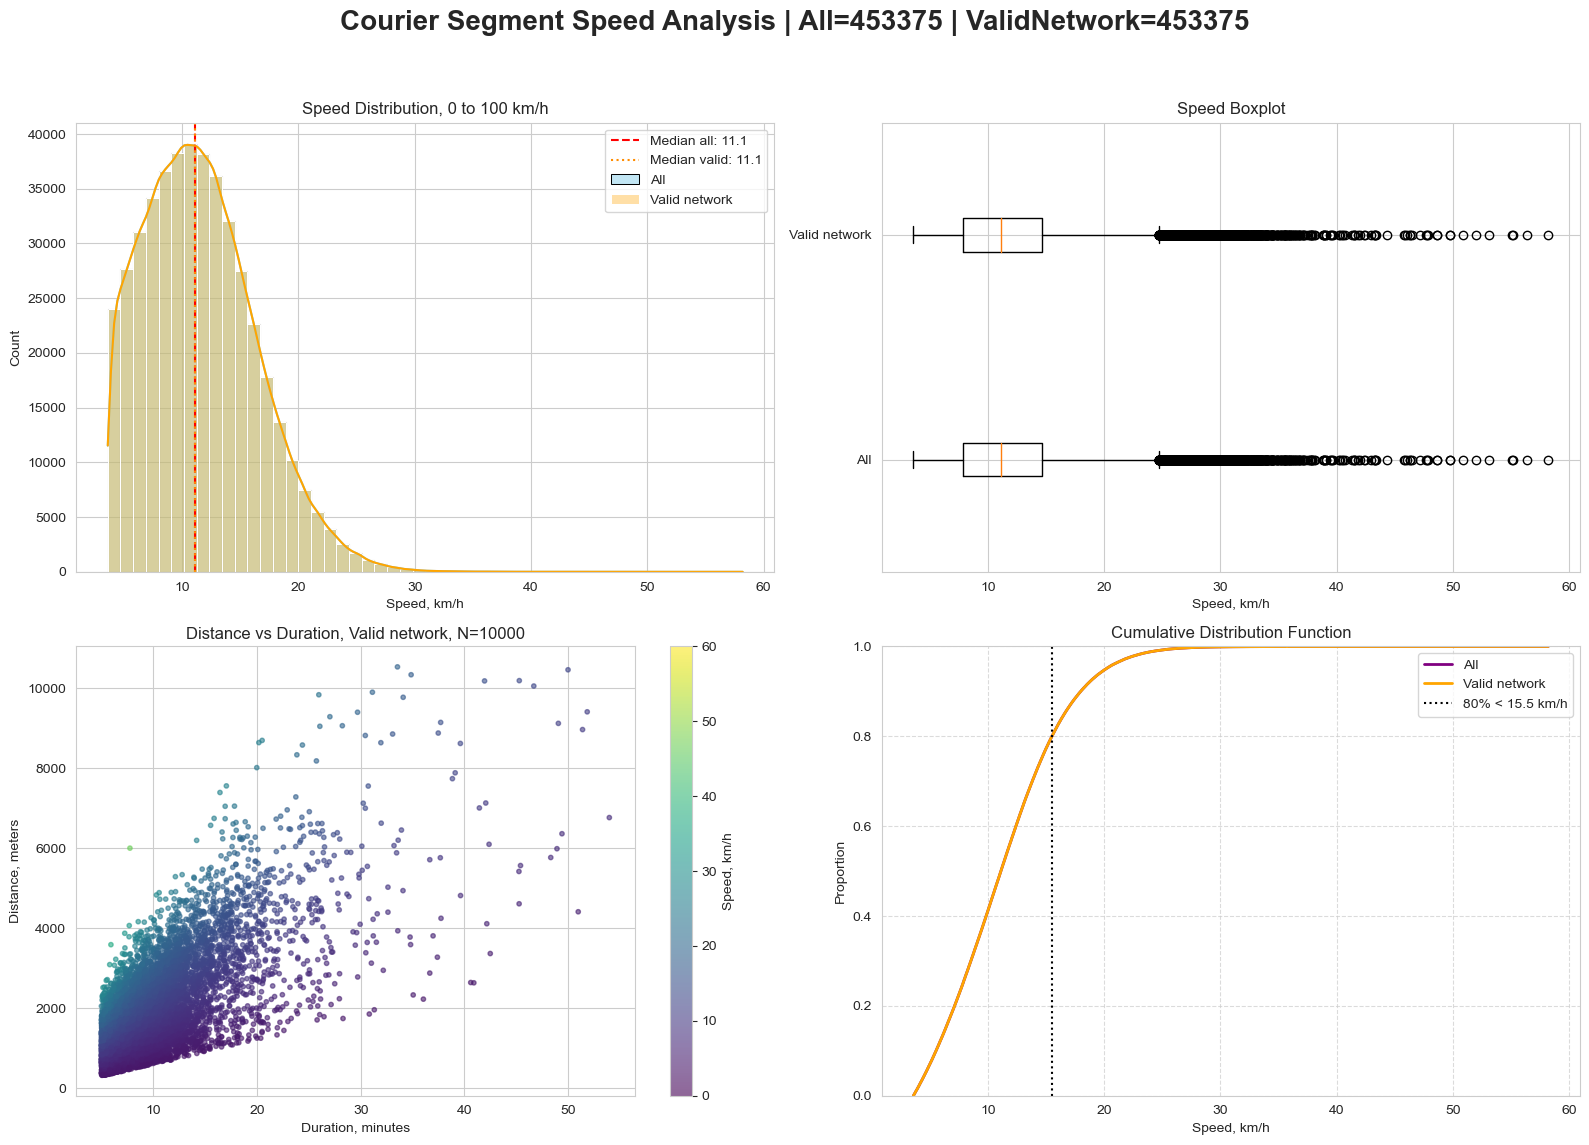

In [12]:
# =========================================================
# 10.2 Speed distribution figure
# =========================================================

if RESUME_SPEED_FIGURES and (not FORCE_REDRAW_SPEED_ANALYSIS) and OUTPUT_FIG_SPEED.exists():
    print("Speed analysis figure already exists, skip redraw:")
    print(OUTPUT_FIG_SPEED)
else:
    print("\n" + "=" * 50)
    print("Speed summary report")
    print("=" * 50)

    stats_all = df["speed_kmh"].describe(
        percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
    )

    print("[All samples]")
    print("Total rows: %d" % int(stats_all["count"]))
    print("Mean speed: %.2f km/h" % stats_all["mean"])
    print("Median speed: %.2f km/h" % stats_all["50%"])
    print("Max speed: %.2f km/h" % stats_all["max"])
    print("1%% quantile: %.2f km/h" % stats_all["1%"])
    print("99%% quantile: %.2f km/h" % stats_all["99%"])

    if len(df_valid) > 0:
        stats_valid = df_valid["speed_kmh"].describe(
            percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
        )

        print("-" * 50)
        print("[Valid network samples]")
        print("Total rows: %d" % int(stats_valid["count"]))
        print("Mean speed: %.2f km/h" % stats_valid["mean"])
        print("Median speed: %.2f km/h" % stats_valid["50%"])
        print("Max speed: %.2f km/h" % stats_valid["max"])
        print("1%% quantile: %.2f km/h" % stats_valid["1%"])
        print("99%% quantile: %.2f km/h" % stats_valid["99%"])

    high_speed = df[df["speed_kmh"] > SPEED_LIMIT_HIGH]
    low_speed = df[df["speed_kmh"] < SPEED_LIMIT_LOW]

    print("-" * 50)
    print(
        "High speed outliers (> %.1f km/h): %d rows, %.2f%%"
        % (SPEED_LIMIT_HIGH, len(high_speed), len(high_speed) / len(df) * 100)
    )
    print(
        "Very low speed rows (< %.1f km/h): %d rows, %.2f%%"
        % (SPEED_LIMIT_LOW, len(low_speed), len(low_speed) / len(df) * 100)
    )

    print("-" * 50)
    print("dist_mode distribution:")
    print(df["dist_mode"].value_counts(dropna=False).to_string())

    print("-" * 50)
    print("calc_method distribution:")
    print(df["calc_method"].value_counts(dropna=False).to_string())

    print("\nDrawing speed analysis figure...")

    sns.set_style("whitegrid")
    plt.rcParams["font.sans-serif"] = ["Arial"]
    plt.rcParams["axes.unicode_minus"] = False

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        "Courier Segment Speed Analysis | All=%d | ValidNetwork=%d"
        % (len(df), len(df_valid)),
        fontsize=20,
        fontweight="bold",
    )

    # 1. Speed histogram
    if len(plot_df) > 0:
        sns.histplot(
            plot_df["speed_kmh"],
            bins=50,
            kde=True,
            color="skyblue",
            edgecolor="black",
            ax=axes[0, 0],
            label="All",
        )

    if len(plot_df_valid) > 0:
        sns.histplot(
            plot_df_valid["speed_kmh"],
            bins=50,
            kde=True,
            color="orange",
            edgecolor=None,
            alpha=0.35,
            ax=axes[0, 0],
            label="Valid network",
        )

    median_all = plot_df["speed_kmh"].median() if len(plot_df) > 0 else np.nan
    if pd.notna(median_all):
        axes[0, 0].axvline(
            median_all,
            color="red",
            linestyle="--",
            label="Median all: %.1f" % median_all,
        )

    if len(plot_df_valid) > 0:
        median_valid = plot_df_valid["speed_kmh"].median()
        axes[0, 0].axvline(
            median_valid,
            color="darkorange",
            linestyle=":",
            label="Median valid: %.1f" % median_valid,
        )

    axes[0, 0].set_title("Speed Distribution, 0 to %d km/h" % MAX_PLOT_SPEED)
    axes[0, 0].set_xlabel("Speed, km/h")
    axes[0, 0].set_ylabel("Count")
    axes[0, 0].legend()

    # 2. Boxplot
    box_data = []
    box_labels = []

    if len(plot_df) > 0:
        box_data.append(plot_df["speed_kmh"].values)
        box_labels.append("All")

    if len(plot_df_valid) > 0:
        box_data.append(plot_df_valid["speed_kmh"].values)
        box_labels.append("Valid network")

    if len(box_data) > 0:
        axes[0, 1].boxplot(box_data, labels=box_labels, vert=False)

    axes[0, 1].set_title("Speed Boxplot")
    axes[0, 1].set_xlabel("Speed, km/h")

    # 3. Distance vs duration scatter
    if len(plot_df_valid) > 0:
        scatter_source = plot_df_valid
        scatter_title_suffix = "Valid network"
    else:
        scatter_source = plot_df
        scatter_title_suffix = "All"

    sample_size = min(SCATTER_SAMPLE_N, len(scatter_source))
    if sample_size > 0:
        sample_df = scatter_source.sample(sample_size, random_state=RANDOM_SEED)

        sc = axes[1, 0].scatter(
            sample_df["duration"] / 60.0,
            sample_df["final_distance_m"],
            c=sample_df["speed_kmh"],
            cmap="viridis",
            alpha=0.6,
            s=10,
            vmin=0,
            vmax=min(60, MAX_PLOT_SPEED),
        )
        cbar = plt.colorbar(sc, ax=axes[1, 0])
        cbar.set_label("Speed, km/h")

    axes[1, 0].set_title(
        "Distance vs Duration, %s, N=%d" % (scatter_title_suffix, sample_size)
    )
    axes[1, 0].set_xlabel("Duration, minutes")
    axes[1, 0].set_ylabel("Distance, meters")

    # 4. Empirical cumulative distribution
    if len(plot_df) > 0:
        sns.ecdfplot(
            data=plot_df,
            x="speed_kmh",
            color="purple",
            linewidth=2,
            ax=axes[1, 1],
            label="All",
        )

    if len(plot_df_valid) > 0:
        sns.ecdfplot(
            data=plot_df_valid,
            x="speed_kmh",
            color="orange",
            linewidth=2,
            ax=axes[1, 1],
            label="Valid network",
        )

    base_for_p80 = plot_df_valid if len(plot_df_valid) > 0 else plot_df
    if len(base_for_p80) > 0:
        p80 = np.percentile(base_for_p80["speed_kmh"], 80)
        axes[1, 1].axvline(
            p80,
            color="black",
            linestyle=":",
            label="80%% < %.1f km/h" % p80,
        )

    axes[1, 1].set_title("Cumulative Distribution Function")
    axes[1, 1].set_xlabel("Speed, km/h")
    axes[1, 1].set_ylabel("Proportion")
    axes[1, 1].grid(True, which="both", linestyle="--", alpha=0.7)
    axes[1, 1].legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    tmp_path = OUTPUT_FIG_SPEED.with_suffix(OUTPUT_FIG_SPEED.suffix + ".tmp.png")
    plt.savefig(tmp_path, dpi=150)
    os.replace(str(tmp_path), str(OUTPUT_FIG_SPEED))

    print("Saved:", OUTPUT_FIG_SPEED)
    plt.show()

### 7.2 Speed by action pair

This figure compares segment speed, duration, and distance by action pair, such as `FETCH -> GRAB`, `GRAB -> DELIVER`, and `FETCH -> DELIVER`.

Original cleaned rows: 453375
Rows used for pair analysis: 453375
Only valid network: True

Action pair summary
| pair_type          |   Count |   Speed_Mean |   Speed_Median |   Speed_Max |   Time_Mean |   Time_Median |   Dist_Mean |   Dist_Median |   NetDist_Mean |   NetDist_Median |
|:-------------------|--------:|-------------:|---------------:|------------:|------------:|--------------:|------------:|--------------:|---------------:|-----------------:|
| FETCH -> DELIVER   |  186745 |        13.05 |          12.81 |       40.57 |      670.99 |           584 |     2387.22 |       2135.56 |        2365.06 |          2112.76 |
| DELIVER -> DELIVER |   93265 |        10.63 |          10.17 |       36.78 |      500.37 |           455 |     1453.96 |       1332.95 |        1431.69 |          1311.01 |
| GRAB -> FETCH      |   72694 |         9.48 |           8.2  |       58.2  |      520.4  |           457 |     1326.56 |       1087.86 |        1305.81 |          1065.84 |
| DELIVER -> 

C:\Users\Kwk10\AppData\Local\Temp\ipykernel_54708\4071801816.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Kwk10\AppData\Local\Temp\ipykernel_54708\4071801816.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Kwk10\AppData\Local\Temp\ipykernel_54708\4071801816.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Kwk10\AppData\Local\Temp\ipykernel_54708\4071801816.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable

Saved: outputs_new_clear\OD\MidPoints\diagnostics\courier_speed_by_pair_filtered.png


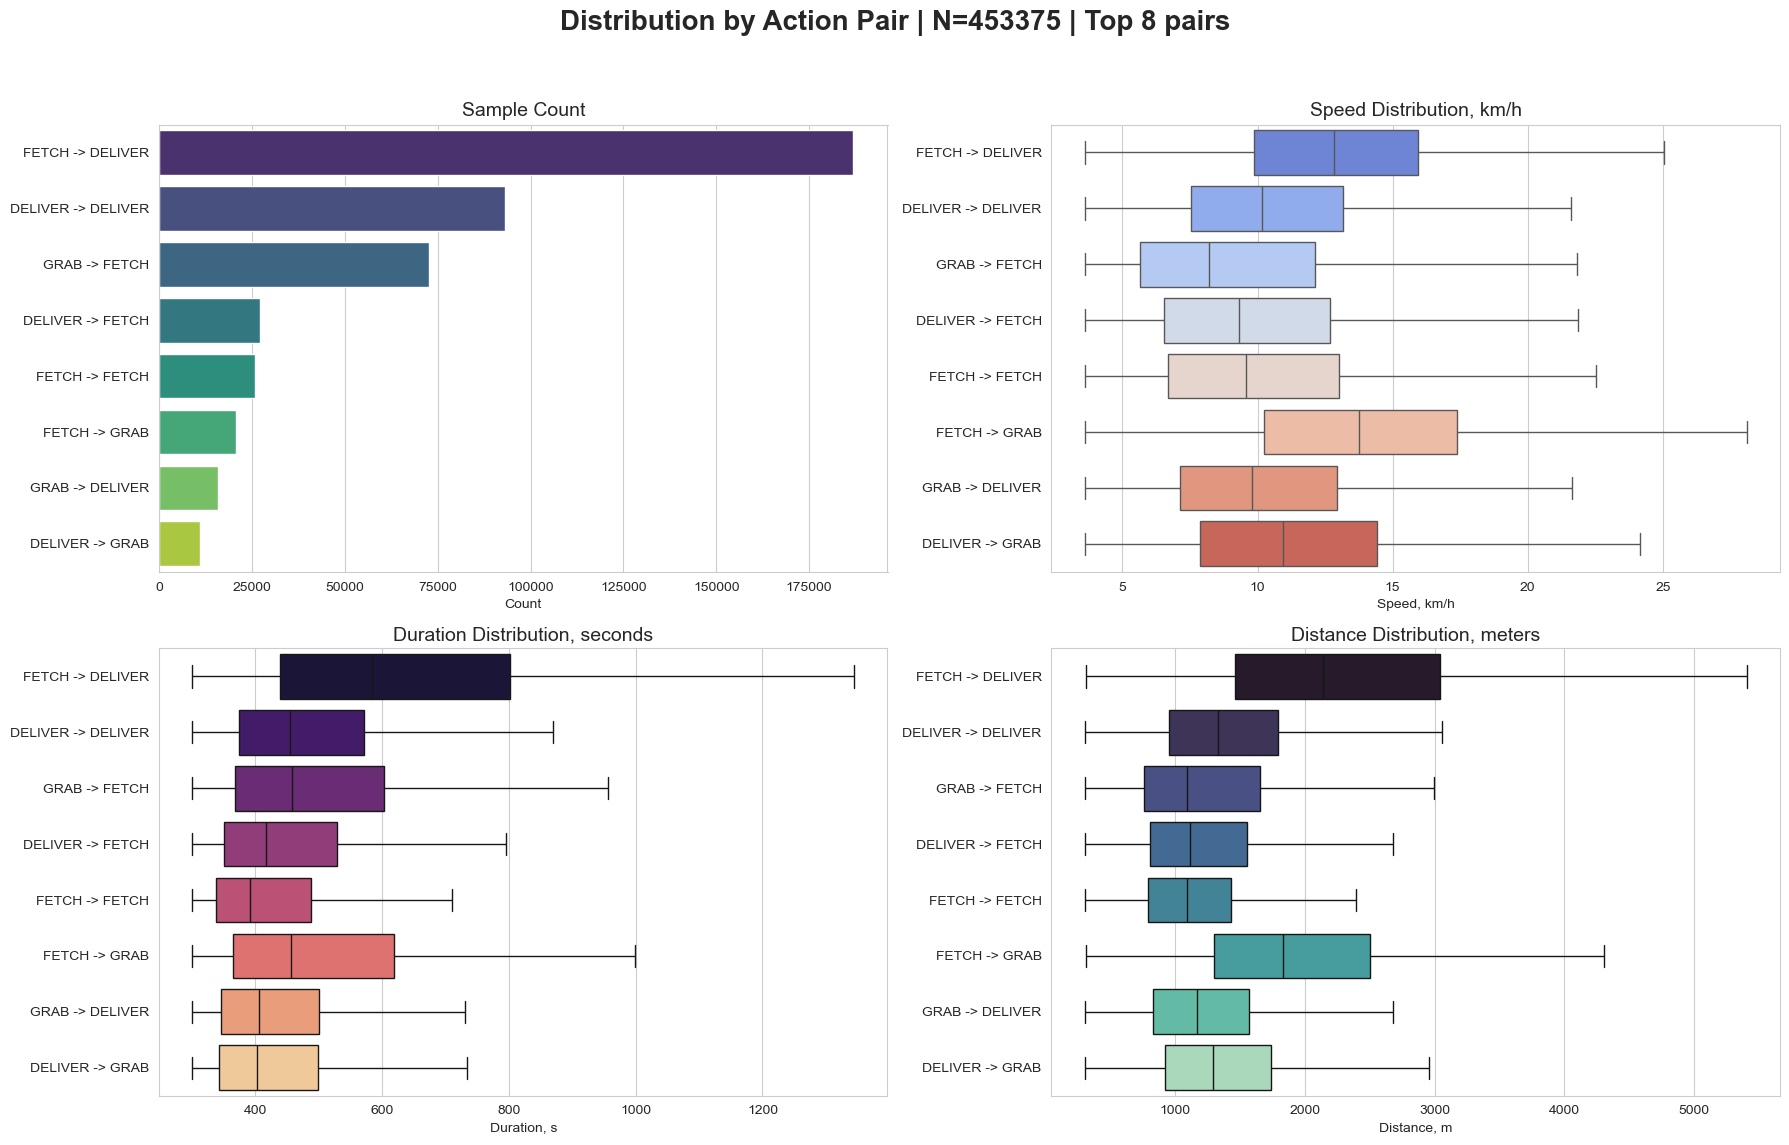


Suggested pair-level speed ranges:
  FETCH -> DELIVER: N=186745, suggested speed range 4.3 to 24.6 km/h, median 12.8 km/h
  DELIVER -> DELIVER: N=93265, suggested speed range 3.9 to 22.2 km/h, median 10.2 km/h
  GRAB -> FETCH: N=72694, suggested speed range 3.7 to 24.7 km/h, median 8.2 km/h
  DELIVER -> FETCH: N=27324, suggested speed range 3.8 to 23.4 km/h, median 9.3 km/h
  FETCH -> FETCH: N=25814, suggested speed range 3.7 to 23.1 km/h, median 9.6 km/h
  FETCH -> GRAB: N=20707, suggested speed range 4.1 to 28.1 km/h, median 13.7 km/h
  GRAB -> DELIVER: N=15875, suggested speed range 3.8 to 23.8 km/h, median 9.8 km/h
  DELIVER -> GRAB: N=10951, suggested speed range 3.8 to 26.5 km/h, median 10.9 km/h


In [13]:
# =========================================================
# 10.3 Speed, duration, and distance by action pair
# =========================================================

if RESUME_SPEED_FIGURES and (not FORCE_REDRAW_PAIR_ANALYSIS) and OUTPUT_FIG_PAIR.exists():
    print("Action-pair figure already exists, skip redraw:")
    print(OUTPUT_FIG_PAIR)

    if OUTPUT_PAIR_STATS_CSV.exists():
        pair_stats = pd.read_csv(OUTPUT_PAIR_STATS_CSV)
        display(pair_stats.head(20))
else:
    required_pair_cols = ["start_action", "end_action"]
    for c in required_pair_cols:
        if c not in df.columns:
            raise ValueError("Missing required column for pair analysis: %s" % c)

    df_pair = df.copy()
    df_pair["pair_type"] = (
        df_pair["start_action"].astype(str) + " -> " + df_pair["end_action"].astype(str)
    )

    if ONLY_VALID_NETWORK:
        used_df = df_pair[df_pair["is_valid_network"]].copy()
    else:
        used_df = df_pair.copy()

    print("Original cleaned rows:", len(df_pair))
    print("Rows used for pair analysis:", len(used_df))
    print("Only valid network:", ONLY_VALID_NETWORK)

    if len(used_df) == 0:
        raise ValueError("No rows available after pair-analysis filters.")

    print("\n" + "=" * 60)
    print("Action pair summary")
    print("=" * 60)

    agg_dict = {
        "speed_kmh": ["count", "mean", "median", "max"],
        "duration": ["mean", "median"],
        "final_distance_m": ["mean", "median"],
    }

    if "dist_network_only" in used_df.columns:
        used_df["dist_network_only"] = pd.to_numeric(
            used_df["dist_network_only"],
            errors="coerce",
        )
        agg_dict["dist_network_only"] = ["mean", "median"]

    pair_stats = used_df.groupby("pair_type").agg(agg_dict).round(2)

    flat_cols = []
    for col in pair_stats.columns:
        if isinstance(col, tuple):
            flat_cols.append("_".join([str(x) for x in col if str(x) != ""]))
        else:
            flat_cols.append(str(col))
    pair_stats.columns = flat_cols

    rename_map = {
        "speed_kmh_count": "Count",
        "speed_kmh_mean": "Speed_Mean",
        "speed_kmh_median": "Speed_Median",
        "speed_kmh_max": "Speed_Max",
        "duration_mean": "Time_Mean",
        "duration_median": "Time_Median",
        "final_distance_m_mean": "Dist_Mean",
        "final_distance_m_median": "Dist_Median",
        "dist_network_only_mean": "NetDist_Mean",
        "dist_network_only_median": "NetDist_Median",
    }
    pair_stats = pair_stats.rename(columns=rename_map)
    pair_stats = pair_stats.sort_values("Count", ascending=False)

    pair_stats_out = pair_stats.reset_index()
    tmp_stats = OUTPUT_PAIR_STATS_CSV.with_suffix(OUTPUT_PAIR_STATS_CSV.suffix + ".tmp")
    pair_stats_out.to_csv(tmp_stats, index=False)
    os.replace(str(tmp_stats), str(OUTPUT_PAIR_STATS_CSV))

    print(pair_stats.to_markdown())
    print("Saved pair stats:", OUTPUT_PAIR_STATS_CSV)

    print("\ndist_mode distribution:")
    print(used_df["dist_mode"].value_counts(dropna=False).to_string())

    print("\ncalc_method distribution:")
    print(used_df["calc_method"].value_counts(dropna=False).to_string())

    print("\nDrawing action-pair comparison figure...")

    sns.set_style("whitegrid")
    plt.rcParams["font.sans-serif"] = ["Arial"]
    plt.rcParams["axes.unicode_minus"] = False

    top_pairs = pair_stats.index[:TOP_K_PAIRS].tolist()
    plot_pair_df = used_df[used_df["pair_type"].isin(top_pairs)].copy()

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(
        "Distribution by Action Pair | N=%d | Top %d pairs"
        % (len(used_df), len(top_pairs)),
        fontsize=20,
        weight="bold",
    )

    sns.countplot(
        y="pair_type",
        data=plot_pair_df,
        order=top_pairs,
        palette="viridis",
        ax=axes[0, 0],
    )
    axes[0, 0].set_title("Sample Count", fontsize=14)
    axes[0, 0].set_xlabel("Count")
    axes[0, 0].set_ylabel("")

    sns.boxplot(
        x="speed_kmh",
        y="pair_type",
        data=plot_pair_df,
        order=top_pairs,
        palette="coolwarm",
        ax=axes[0, 1],
        showfliers=False,
    )
    axes[0, 1].set_title("Speed Distribution, km/h", fontsize=14)
    axes[0, 1].set_xlabel("Speed, km/h")
    axes[0, 1].set_ylabel("")

    sns.boxplot(
        x="duration",
        y="pair_type",
        data=plot_pair_df,
        order=top_pairs,
        palette="magma",
        ax=axes[1, 0],
        showfliers=False,
    )
    axes[1, 0].set_title("Duration Distribution, seconds", fontsize=14)
    axes[1, 0].set_xlabel("Duration, s")
    axes[1, 0].set_ylabel("")

    sns.boxplot(
        x="final_distance_m",
        y="pair_type",
        data=plot_pair_df,
        order=top_pairs,
        palette="mako",
        ax=axes[1, 1],
        showfliers=False,
    )
    axes[1, 1].set_title("Distance Distribution, meters", fontsize=14)
    axes[1, 1].set_xlabel("Distance, m")
    axes[1, 1].set_ylabel("")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    tmp_path = OUTPUT_FIG_PAIR.with_suffix(OUTPUT_FIG_PAIR.suffix + ".tmp.png")
    plt.savefig(tmp_path, dpi=150)
    os.replace(str(tmp_path), str(OUTPUT_FIG_PAIR))

    print("Saved:", OUTPUT_FIG_PAIR)
    plt.show()

    print("\nSuggested pair-level speed ranges:")
    for pair in top_pairs:
        subset = used_df[used_df["pair_type"] == pair].copy()
        if len(subset) == 0:
            continue

        p99 = subset["speed_kmh"].quantile(0.99)
        p01 = subset["speed_kmh"].quantile(0.01)
        med = subset["speed_kmh"].median()
        n = len(subset)

        print(
            "  %s: N=%d, suggested speed range %.1f to %.1f km/h, median %.1f km/h"
            % (pair, n, p01, p99, med)
        )